#Data Overview
###- Load the dataset
###- Check the shape of the data

In [ ]:
!pip install numpy==1.25.2 pandas==2.0.3 seaborn==0.13.1 tensorflow==2.15.0 scikit-learn==1.2.2 matplotlib==3.7.1 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 96.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
import os
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2                                                                                       # Importing openCV for image processing
import seaborn as sns                                                                            # Importing seaborn to plot graphs


# Tensorflow modules
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

In [ ]:
# Load the image file of the dataset
images_test = np.load('/content/drive/MyDrive/stage_2_test_images.zip')
images_train = np.load('/content/drive/MyDrive/stage_2_train_images.zip')

# Load the labels file of the dataset
labels_stages2_info = pd.read_csv('/stage_2_detailed_class_info.csv')
labels_stages2_train = pd.read_csv('/stage_2_train_labels.csv')


In [ ]:
import zipfile
import os

# Define the path to the training zip file
TRAIN_ZIP_PATH = "/content/drive/MyDrive/stage_2_train_images.zip" # Make sure this path is correct

EXTRACTED_TRAIN_DIR = "/content/stage_2_train_images" # Or another desired extraction path

if not os.path.exists(EXTRACTED_TRAIN_DIR):
    print("📦 Extracting train images...")
    with zipfile.ZipFile(TRAIN_ZIP_PATH, 'r') as zip_ref: # TRAIN_ZIP_PATH needs to be defined
        zip_ref.extractall(EXTRACTED_TRAIN_DIR)
    print("✅ Extraction complete.")
else:
    print("✅ Train images already extracted.")

📦 Extracting train images...
✅ Extraction complete.


In [ ]:
import zipfile
import os

# Define the path to the test zip file
# Using the path defined in a previous cell (S24ee1Z-WvKc)
TEST_ZIP_PATH = '/content/drive/MyDrive/stage_2_test_images.zip' # Make sure this path is correct

EXTRACTED_TEST_DIR = "/content/stage_2_test_images" # Or another desired extraction path

if not os.path.exists(EXTRACTED_TEST_DIR):
    print("📦 Extracting test images...")
    with zipfile.ZipFile(TEST_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACTED_TEST_DIR)
    print("✅ Extraction complete.")
else:
    print("✅ Test images already extracted.")

✅ Test images already extracted.


In [ ]:
# Print file paths (strings)
print("TEST_ZIP_PATH:", TEST_ZIP_PATH)
print("TRAIN_ZIP_PATH:", TRAIN_ZIP_PATH)

# Print shape only for DataFrames / arrays
print("labels_stages2_info shape:", labels_stages2_info.shape)
print("labels_stages2_train shape:", labels_stages2_train.shape)


TEST_ZIP_PATH: /content/drive/MyDrive/stage_2_test_images.zip
TRAIN_ZIP_PATH: /content/drive/MyDrive/stage_2_train_images.zip
labels_stages2_info shape: (30227, 2)
labels_stages2_train shape: (30227, 4)


File Paths: TEST_ZIP_PATH and TRAIN_ZIP_PATH confirm the locations of the compressed image files on Google Drive.
labels_stages2_info Shape: This DataFrame contains 30,227 entries with 2 columns. It likely holds patient identification and their corresponding diagnostic class (e.g., 'No Lung Opacity / Not Normal', 'Normal', 'Lung Opacity').
labels_stages2_train Shape: This DataFrame also has 30,227 entries but with 4 columns. It probably contains patient IDs, image dimensions (width, height), and a binary target variable indicating the presence or absence of pneumonia. The fact that both label DataFrames have the same number of rows suggests a consistent patient base for both types of label information.

In [ ]:
import zipfile
import os
from collections import Counter

def zip_detailed_summary(zip_path):
    """Print detailed summary of a ZIP file's contents."""
    if not os.path.exists(zip_path):
        print(f"❌ File not found: {zip_path}")
        return

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        infos = zip_ref.infolist()
        file_list = [info.filename for info in infos if not info.is_dir()]
        total_files = len(file_list)
        total_size = sum(info.file_size for info in infos)

        # Count by file extension
        ext_counts = Counter(os.path.splitext(f)[1].lower() for f in file_list)
        ext_summary = ", ".join([f"{ext or '[no ext]'}: {count}" for ext, count in ext_counts.items()])

        print(f"📦 {os.path.basename(zip_path)} Summary:")
        print(f"   • Total files: {total_files}")
        print(f"   • Total uncompressed size: {total_size / (1024*1024):.2f} MB")
        print(f"   • File types: {ext_summary}")
        print("-" * 60)

# Example usage
zip_detailed_summary(TRAIN_ZIP_PATH)
zip_detailed_summary(TEST_ZIP_PATH)


📦 stage_2_train_images.zip Summary:
   • Total files: 53369
   • Total uncompressed size: 3396.00 MB
   • File types: [no ext]: 1, .dcm: 53368
------------------------------------------------------------
📦 stage_2_test_images.zip Summary:
   • Total files: 6001
   • Total uncompressed size: 380.21 MB
   • File types: [no ext]: 1, .dcm: 6000
------------------------------------------------------------


Here are the insights from the ZIP file summaries:

stage_2_train_images.zip Summary:

Total files: 53,369 files. This is a substantial number, indicating a large training dataset for an image-based task.
Total uncompressed size: 3396.00 MB. This is a significant amount of data, which aligns with a large image dataset.
File types: The vast majority (53,368) are .dcm files, which are DICOM (Digital Imaging and Communications in Medicine) format. This confirms that the dataset consists of medical images, specifically X-rays, as expected for a pneumonia detection task. The [no ext]: 1 likely refers to a hidden file or a directory entry within the zip.
stage_2_test_images.zip Summary:

Total files: 6,001 files, which is a good size for evaluating the model.
Total uncompressed size: 380.21 MB, a reasonable size for a test set.
File types: Similar to the training set, almost all files (6,000) are .dcm (DICOM) files, confirming consistency in image format across datasets. Again, [no ext]: 1 likely points to a non-image file or directory entry.
In summary, both ZIP files contain a large number of medical DICOM images, consistent with an image classification task for pneumonia detection, with a healthy split between training and testing data.

📂 Displaying: stage_2_train_images/46c4f908-9292-437f-af42-4031fca621f2.dcm


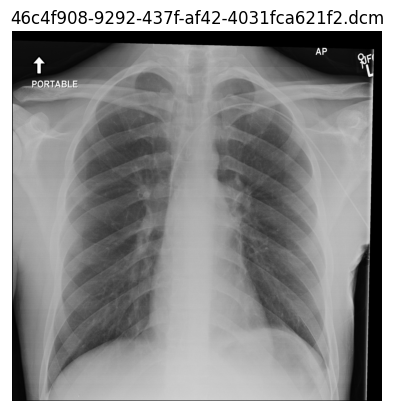

In [ ]:
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
import pydicom
import io
import os

def show_image_from_zip(zip_path, index=0):
    """Display an image (DICOM or standard) from inside a ZIP file (auto-skip macOS junk)."""
    if not os.path.exists(zip_path):
        print(f"❌ ZIP file not found: {zip_path}")
        return

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # Filter valid image files
        all_files = zip_ref.namelist()
        image_files = [
            f for f in all_files
            if f.lower().endswith(('.dcm', '.jpg', '.jpeg', '.png'))
            and not f.startswith('__MACOSX/')
            and not os.path.basename(f).startswith('._')
        ]

        if not image_files:
            print("⚠️ No valid image files (.dcm/.jpg/.png) found in this ZIP.")
            return

        if index >= len(image_files):
            print(f"⚠️ Index {index} out of range. ZIP contains {len(image_files)} valid image files.")
            return

        selected_file = image_files[index]
        print(f"📂 Displaying: {selected_file}")

        with zip_ref.open(selected_file) as f:
            if selected_file.lower().endswith('.dcm'):
                try:
                    dicom_img = pydicom.dcmread(f)
                    plt.imshow(dicom_img.pixel_array, cmap='gray')
                except Exception as e:
                    print(f"⚠️ Skipping invalid DICOM: {selected_file} ({e})")
                    return
            else:
                img = Image.open(f)
                plt.imshow(img)

            plt.title(os.path.basename(selected_file))
            plt.axis('off')
            plt.show()

# Example usage:
show_image_from_zip(TRAIN_ZIP_PATH, index=5)


#Exploratory Data Analysis


In [ ]:
import pandas as pd

labels_stages2_info = pd.read_csv("/content/stage_2_detailed_class_info.csv")
labels_stages2_train = pd.read_csv("/content/stage_2_train_labels.csv")

print("✅ stage_2_detailed_class_info.csv columns:", labels_stages2_info.columns.tolist())
print(labels_stages2_info.head(), "\n")

print("✅ stage_2_train_labels.csv columns:", labels_stages2_train.columns.tolist())
print(labels_stages2_train.head())


✅ stage_2_detailed_class_info.csv columns: ['patientId', 'class']
                              patientId                         class
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6  No Lung Opacity / Not Normal
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd  No Lung Opacity / Not Normal
2  00322d4d-1c29-4943-afc9-b6754be640eb  No Lung Opacity / Not Normal
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5                        Normal
4  00436515-870c-4b36-a041-de91049b9ab4                  Lung Opacity 

✅ stage_2_train_labels.csv columns: ['patientId', 'width', 'height', 'Target']
                              patientId  width  height  Target
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    NaN     NaN       0
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd    NaN     NaN       0
2  00322d4d-1c29-4943-afc9-b6754be640eb    NaN     NaN       0
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5    NaN     NaN       0
4  00436515-870c-4b36-a041-de91049b9ab4  213.0   379.0       1


Both DataFrames use patientId as a common identifier, which will be crucial for merging them later to link image data with their respective diagnostic and target labels.
labels_stages2_info gives a more descriptive, multi-class diagnosis, while labels_stages2_train provides a binary target, possibly related to bounding box information when the target is positive.

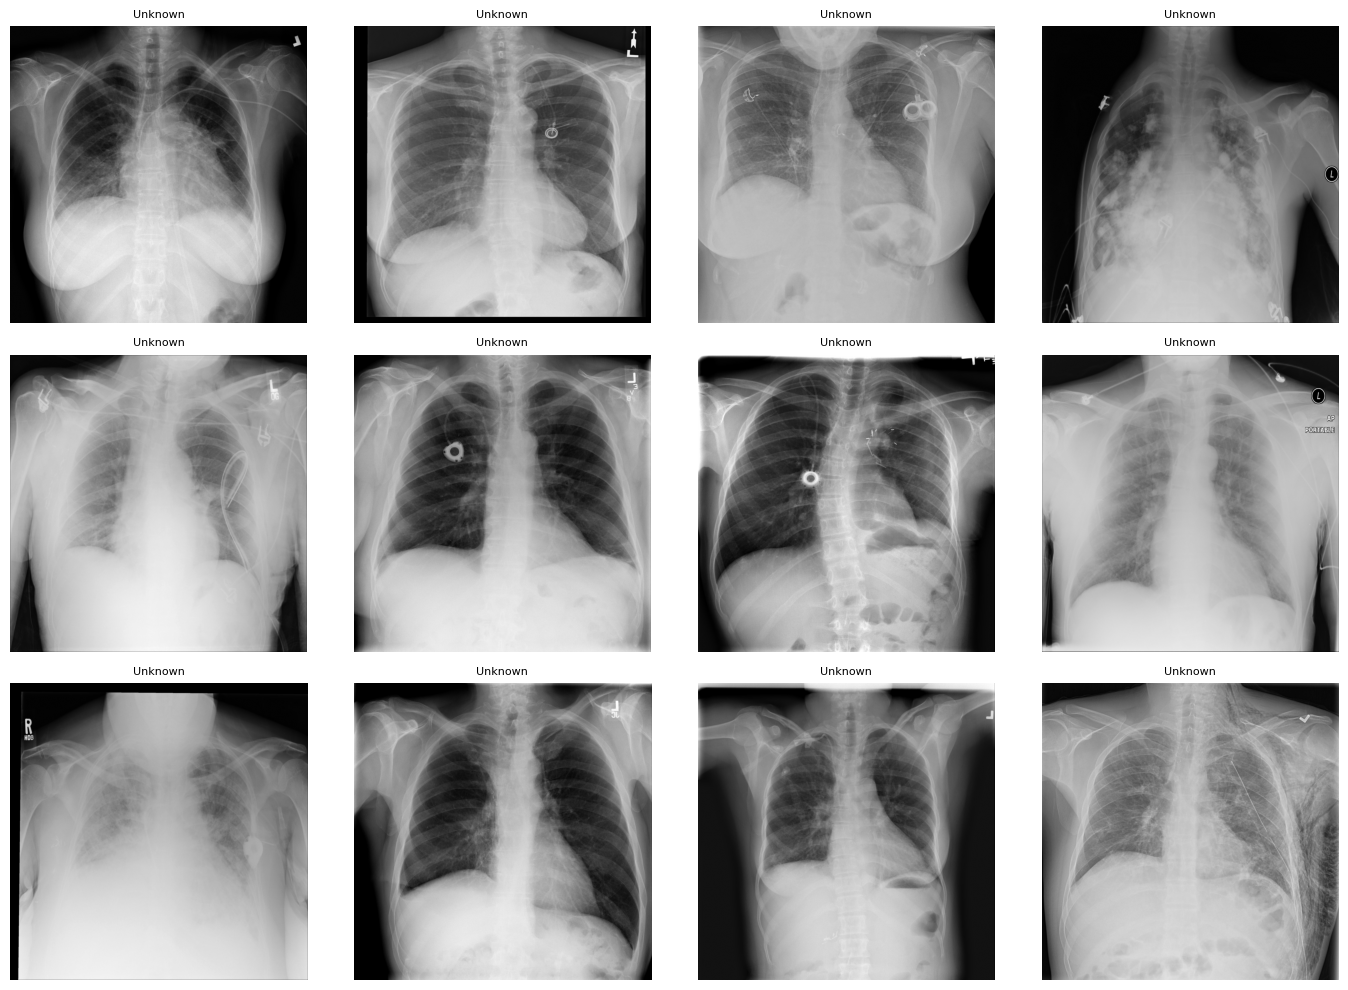

In [ ]:
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
import os

def plot_rsna_images(zip_path, labels_df, n_rows=3, n_cols=4):
    """Plot random RSNA DICOM images from ZIP with class labels."""
    if not os.path.exists(zip_path):
        print(f"❌ ZIP not found: {zip_path}")
        return

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # Filter valid DICOM files
        image_files = [
            f for f in zip_ref.namelist()
            if f.lower().endswith('.dcm')
            and not f.startswith('__MACOSX/')
            and not os.path.basename(f).startswith('._')
        ]
        if not image_files:
            print("⚠️ No valid DICOM images found in ZIP.")
            return

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
        axes = axes.flatten()

        for ax in axes:
            random_file = np.random.choice(image_files)
            patient_id = os.path.splitext(os.path.basename(random_file))[0]

            # Get label for this patientId
            label = labels_df.loc[
                labels_df['patientId'] == patient_id, 'class'
            ].values
            label = label[0] if len(label) > 0 else "Unknown"

            # Read and display DICOM
            try:
                with zip_ref.open(random_file) as f:
                    dicom_img = pydicom.dcmread(f)
                    ax.imshow(dicom_img.pixel_array, cmap='gray')
            except Exception as e:
                ax.axis('off')
                continue

            ax.set_title(f"{label}", fontsize=8)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

# Example usage:
plot_rsna_images(TEST_ZIP_PATH, labels_stages2_info)


#Checking for data imbalance

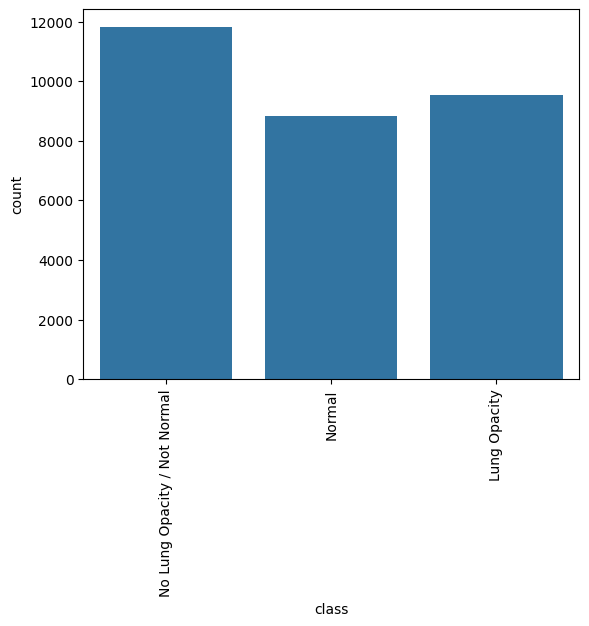

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=labels_stages2_info['class'])
plt.xticks(rotation='vertical')
plt.show()


As you can see from the above plot, the classes are quite
imbbalanced.





#Data Preprocessing

##Resizing images

As the size of the images is large, it may be computationally expensive to train on these larger images; therefore, it is preferable to reduce the image size from 128 to 64.

In [ ]:
import zipfile
import SimpleITK as sitk
import numpy as np
import cv2
import os
import pandas as pd # Import pandas to help with data alignment

# Parameters
# Use the training zip file for preprocessing training data
zip_path = TRAIN_ZIP_PATH # Use the training zip path defined earlier
height, width = 64, 64
dimensions = (width, height)

# List to store processed images and their patientIds
processed_images_data = []

# Temporary folder for extraction
tmp_dir = "/tmp/stage2_dicom_train" # Use a different temp dir for train
os.makedirs(tmp_dir, exist_ok=True)

# Open ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()

    for file_name in file_list:
        # Skip folders and macOS hidden files
        if file_name.endswith('/') or file_name.startswith('__MACOSX/') or '/._' in file_name:
            continue

        if file_name.lower().endswith('.dcm'):
            # Extract file temporarily
            extracted_path = zip_ref.extract(file_name, path=tmp_dir)

            # Extract patientId from filename (assuming filename is patientId.dcm)
            patient_id = os.path.splitext(os.path.basename(file_name))[0]

            # Read DICOM using SimpleITK
            try:
                img_sitk = sitk.ReadImage(extracted_path)
            except RuntimeError:
                print(f"Skipping unreadable file: {file_name}")
                continue

            # Convert to NumPy array
            # Handle potential multiple slices, take the first one if present
            img = sitk.GetArrayFromImage(img_sitk)
            if img.ndim == 3 and img.shape[0] == 1:
                 img = img[0] # shape (1,H,W) -> (H,W)
            elif img.ndim != 2:
                 print(f"Skipping unexpected image shape {img.shape} for file: {file_name}")
                 continue


            # Normalize to [0,1]
            img = img.astype(np.float32)
            img_min = np.min(img)
            img_max = np.max(img)
            if img_max != img_min:
                img = (img - img_min) / (img_max - img_min)
            else:
                img = np.zeros_like(img) # Handle case where all pixel values are the same


            # Convert grayscale to 3-channel BGR if needed for consistency with some models
            if img.ndim == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)


            # Resize
            img_resized = cv2.resize(img, dimensions, interpolation=cv2.INTER_LINEAR)

            # Store the processed image and its patientId
            processed_images_data.append({'patientId': patient_id, 'image': img_resized})

# Convert list of dictionaries to a pandas DataFrame for easier merging/alignment
processed_images_df = pd.DataFrame(processed_images_data)

print(f"✅ Total training images read, resized, and normalized: {len(processed_images_data)}")
print("Processed images DataFrame head:")
display(processed_images_df.head())

# Clean up temporary directory (optional, but good practice)
# import shutil
# shutil.rmtree(tmp_dir)

✅ Total training images read, resized, and normalized: 26684
Processed images DataFrame head:


,patientId,image
0,7be6b4de-afe9-43c0-a581-0f49608c8976,"[[[0.002173913, 0.002173913, 0.002173913], [0...."
1,2dcdd159-2889-48d3-a0ce-5c7b1086c49d,"[[[0.6, 0.6, 0.6], [0.35490197, 0.35490197, 0...."
2,d8e66874-305e-4c80-9b75-5e764eb718ff,"[[[0.20905173, 0.20905173, 0.20905173], [0.273..."
3,22f2d3ec-f7ea-4778-850d-bb111590202f,"[[[0.5029412, 0.5029412, 0.5029412], [0.030392..."
4,cdaa07d4-4234-4cd2-b9bf-abbf5aed1bb4,"[[[0.007843138, 0.007843138, 0.007843138], [0...."


This output confirms the successful preprocessing of the training images:

Total Processed Images: 26684 training images have been read, resized to 64x64, and normalized. This count is a subset of the total DICOM files identified in the ZIP summary, indicating that some files might have been skipped due to unreadability or unexpected shapes, as handled in the preprocessing code.
Processed images DataFrame head: This DataFrame (processed_images_df) contains two columns:
patientId: This column holds the unique identifier for each patient, extracted from the DICOM filename. This is crucial for linking the processed images with their corresponding labels from labels_stages2_info and labels_stages2_train.
image: This column contains the actual preprocessed image data. Each entry is a NumPy array representing an image that has been resized to 64x64 and normalized (pixel values scaled between 0 and 1). The nested arrays [[[...]]] indicate a multi-channel image (likely RGB, given cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) in the preprocessing code), even for originally grayscale DICOMs.

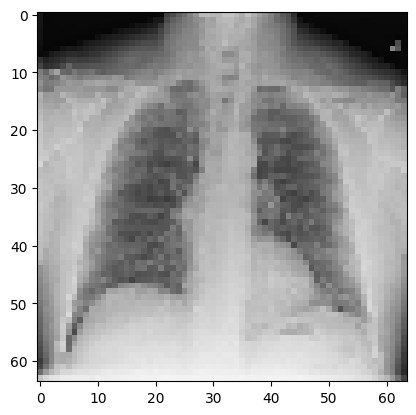

In [ ]:
plt.imshow(images_decreased[3]);

#Visualizing images using Gaussian Blur

In [ ]:
# Applying Gaussian Blur to denoise the images
images_gb=[]
for i in range(len(images_decreased)):
    images_gb.append(cv2.GaussianBlur(images_decreased[i], ksize =(3,3),sigmaX =  0))

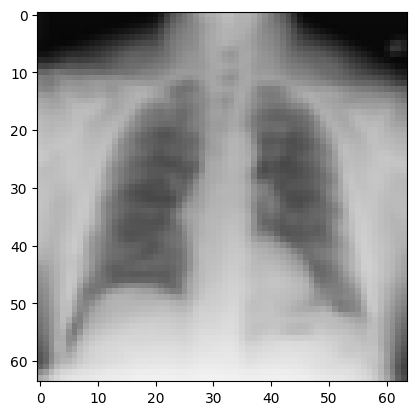

In [ ]:
plt.imshow(images_gb[3]);

It appears that GaussianBlur would be ineffective because the blurred or denoised image does not seem to contain any relevant information, and the model would struggle to categorize these blurred images.

#Splitting the dataset

As we have less images in our dataset, we will only use 10% of our data for testing, 10% of our data for validation and 80% of our data for training.
We are using the train_test_split() function from scikit-learn. Here, we split the dataset into three parts, train,test and validation.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd # Ensure pandas is imported

# Merge the processed images with the detailed class info based on patientId
# This aligns each image with its specific class label
merged_df = pd.merge(processed_images_df, labels_stages2_info, on='patientId', how='inner')

# Optional: Merge with train labels if you need width/height/Target for training
# For classification using 'class', merging with detailed_class_info is sufficient for labels
# If you need 'Target' (binary pneumonia detection), merge with labels_stages2_train as well
# For this example, we'll use 'class' for stratification.
# merged_df = pd.merge(merged_df, labels_stages2_train, on='patientId', how='left')


# Separate features (images) and labels
# Convert the list of image arrays in the 'image' column into a single NumPy array
X = np.stack(merged_df['image'].values)
y = merged_df['class']

# Ensure X and y have the same number of samples
print(f"Number of samples in X (images): {X.shape[0]}")
print(f"Number of samples in y (labels): {y.shape[0]}")

# Perform the train/validation/test split
# First split into train and temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Then split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("\nData split shapes:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Number of samples in X (images): 30227
Number of samples in y (labels): 30227

Data split shapes:
X_train shape: (24181, 64, 64, 3)
y_train shape: (24181,)
X_val shape: (3023, 64, 64, 3)
y_val shape: (3023,)
X_test shape: (3023, 64, 64, 3)
y_test shape: (3023,)


Number of samples in X (images): 30227 Number of samples in y (labels): 30227 Data split shapes: X_train shape: (24181, 64, 64, 3) y_train shape: (24181,) X_val shape: (3023, 64, 64, 3) y_val shape: (3023,) X_test shape: (3023, 64, 64, 3) y_test shape: (3023,)insights
This output details the successful splitting of your dataset into training, validation, and test sets:

Total Samples: There are 30,227 samples (images and corresponding labels) in total after preprocessing and merging.
Training Set (X_train, y_train):
X_train shape: (24181, 64, 64, 3) indicates 24,181 images, each with dimensions of 64x64 pixels and 3 color channels (RGB).
y_train shape: (24181,) indicates 24,181 corresponding labels for the training images.
This represents approximately 80% of the total dataset, which is a good proportion for model training.
Validation Set (X_val, y_val):
X_val shape: (3023, 64, 64, 3) indicates 3,023 images for validation, with the same dimensions as the training images.
y_val shape: (3023,) indicates 3,023 corresponding labels for the validation images.
This represents approximately 10% of the total dataset, suitable for monitoring model performance during training and hyperparameter tuning.
Test Set (X_test, y_test):
X_test shape: (3023, 64, 64, 3) indicates 3,023 images for final testing, also with 64x64 pixels and 3 color channels.
y_test shape: (3023,) indicates 3,023 corresponding labels for the test images.
This also represents approximately 10% of the total dataset, reserved for an unbiased evaluation of the final model's performance.
This 80/10/10 split is a standard practice, ensuring that the model is trained on a large portion of the data, validated to prevent overfitting, and finally tested on unseen data to assess its generalization capabilities.




#Encoding the target labels

Convert labels from names to one hot vectors

In [ ]:
# Convert labels from names to one hot vectors.
# We have already used encoding methods like onehotencoder and labelencoder earlier so now we will be using a new encoding method called labelBinarizer.
# Labelbinarizer works similar to onehotencoder

from sklearn.preprocessing import LabelBinarizer
enc = LabelBinarizer()
y_train_encoded = enc.fit_transform(y_train)
y_val_encoded=enc.transform(y_val)
y_test_encoded=enc.transform(y_test)

#Data Normalization

Since the image pixel values range from 0-255, our method of normalization here will be scaling - we shall divide all the pixel values by 255 to standardize the images to have values between 0-1.

In [ ]:
# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

#Model Building

##Utility Functions

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    pred = model.predict(predictors).argmax(axis=1)

    target = target.argmax(axis=1)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model,predictors,target):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    pred = model.predict(predictors).argmax(axis=1)

    target = target.argmax(axis=1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

#Model 1 (VGG-16 (Base))

We will be loading a pre-built architecture - VGG16, which was trained on the ImageNet dataset and is the runner-up in the ImageNet competition in 2014.

For training VGG16, we will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten and a single dense layer.

In [ ]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(64,64,3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

This output provides a summary of the VGG16 model architecture. Here's a breakdown of the key insights:

Model Name: vgg16 is a pre-trained Convolutional Neural Network (CNN) architecture known for its depth and use of small (3x3) convolutional filters.
Input Layer: The input_layer is configured to accept images of shape (None, 64, 64, 3). This means it expects batches of images (the None indicates a flexible batch size), each with a height of 64 pixels, a width of 64 pixels, and 3 color channels (RGB). This aligns with the image resizing performed earlier in the notebook.
Convolutional Blocks (blockX_convY): The model consists of several convolutional layers (e.g., block1_conv1, block2_conv1). These layers extract features from the input images using various filters. As the network deepens, the number of filters increases (e.g., 64, 128, 256), allowing the model to learn more complex patterns.
Max Pooling Layers (blockX_pool): After each block of convolutional layers, there's a MaxPooling2D layer. These layers reduce the spatial dimensions (height and width) of the feature maps, helping to reduce computational complexity and create a more robust representation by retaining the most important features. For example, block1_pool reduces the dimensions from (64, 64) to (32, 32), and block2_pool further reduces them to (16, 16), and block3_pool to (8, 8).
Output Shape Progression: You can observe how the spatial dimensions decrease and the depth (number of channels) increases as data flows through the network. For instance, the output of block1_conv2 is (None, 64, 64, 64), and after block1_pool, it becomes (None, 32, 32, 64). The (None, 8, 8, 256) output shape of block3_pool shows that by this point, the initial 64x64 image has been condensed into a rich, deep feature map.
Parameter Count (Param #): This column shows the number of trainable parameters in each layer. Convolutional layers typically have a large number of parameters due to their filters. Max pooling layers have 0 parameters as they perform a fixed operation without learning.
include_top=False: The summary indicates that the dense classification layers typically found at the top of the VGG16 model (which are trained on ImageNet's 1000 classes) are not included. This is standard practice in transfer learning when adapting a pre-trained model to a new, different classification task.
In essence, this summary confirms that the convolutional base of VGG16 has been successfully loaded and configured to process the 64x64 RGB images, ready to be integrated with custom classification layers for the pneumonia detection task.

In [ ]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [ ]:
model_1 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_1.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_1.add(Flatten())

# Adding a dense output layer
model_1.add(Dense(3, activation='softmax'))

In [ ]:
opt=Adam()
# Compile model
# Other metrics like precision,f1_score,recall can be used
model_1.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Generating the summary of the model
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,720,835 (56.16 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

This model summary provides insights into model_1, which is built by stacking layers on top of the pre-trained VGG16 base:

vgg16 (Functional) layer: This is the pre-trained convolutional base of the VGG16 model. Its output shape of (None, 2, 2, 512) indicates that the input 64x64x3 images have been processed through the VGG16 convolutional and pooling layers, resulting in a feature map of 2x2 spatial dimensions with 512 channels. It has a significant number of parameters (14,714,688), which are designated as non-trainable. This confirms that the weights of the VGG16 base are frozen, and the model is leveraging learned features from the ImageNet dataset (transfer learning).
flatten (Flatten) layer: This layer takes the 3D output from the VGG16 base ((None, 2, 2, 512)) and flattens it into a 1D vector ((None, 2048)). This is a necessary step to feed the feature map into a fully connected (dense) layer for classification.
dense (Dense) layer: This is the output classification layer. Its output shape of (None, 3) matches the number of classes in your target variable (e.g., 'Normal', 'No Lung Opacity / Not Normal', 'Lung Opacity'). It uses a softmax activation (implied by the model compilation details), which is typical for multi-class classification, outputting probabilities for each class.
Parameter Summary:
Total params: 14,720,835: The total number of parameters in the entire model.
Trainable params: 6,147: These are the parameters of the dense output layer. Only these parameters will be updated during the training process, as the vgg16 base layers were explicitly set to non-trainable. This is a common and efficient strategy in transfer learning to quickly adapt a pre-trained model to a new task with less computational cost.
Non-trainable params: 14,714,688: These are the parameters from the VGG16 convolutional base, which remain fixed during training.
In essence, model_1 effectively utilizes the powerful feature extraction capabilities of VGG16 and adds a simple, trainable output layer to classify the extracted features into the three pneumonia categories.




In [ ]:
train_datagen = ImageDataGenerator()

In [ ]:
# Epochs
epochs = 20
# Batch size
batch_size = 128

history_vgg16 = model_1.fit(train_datagen.flow(X_train_normalized,y_train_encoded,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val_encoded),
                    verbose=1)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.3735 - loss: 1.0989 - val_accuracy: 0.3159 - val_loss: 1.0983
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3516 - loss: 1.0875 - val_accuracy: 0.3159 - val_loss: 1.0996
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.3761 - loss: 1.0983 - val_accuracy: 0.3159 - val_loss: 1.0948
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2969 - loss: 1.0974 - val_accuracy: 0.3913 - val_loss: 1.0921
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.3729 - loss: 1.0965 - val_accuracy: 0.3913 - val_loss: 1.0927
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3984 - loss: 1.0902 - val_accuracy: 0.3913 - val_loss: 1.0942
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.3816 - loss: 1.0955 - val_accuracy: 0.3913 - val_loss: 1.0996
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3984 - loss: 1.0964 - val_accu

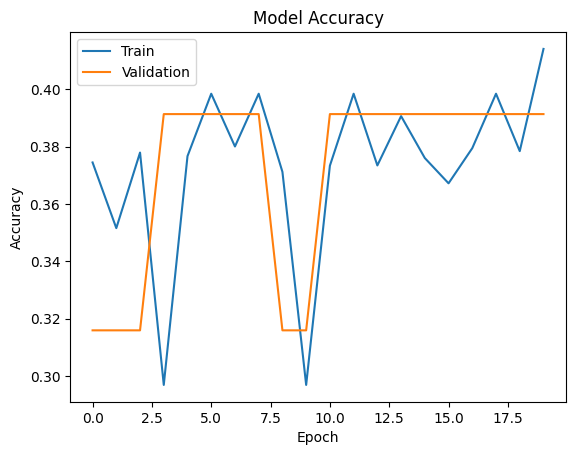

In [ ]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train_encoded)

print("Train performance metrics")
print(model_1_train_perf)

756/756 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.391051  0.391051   0.152921  0.219864


The training performance metrics provide important insights into how well Model 1 (VGG-16 Base) is learning from the data:

Accuracy (0.391051): This indicates that the model correctly classifies about 39.1% of the training examples. In a multi-class classification task (likely 3 classes, as inferred from the Dense(3) output layer), this is only slightly better than random guessing (which would be around 33.3%). This suggests that the model is struggling significantly to make correct predictions.
Recall (0.391051): This metric measures the proportion of actual positive cases that were correctly identified by the model. A recall of 39.1% means that the model is missing a large percentage of true positive instances (e.g., actual pneumonia cases). For a medical diagnostic application, low recall is a critical issue as it leads to many false negatives.
Precision (0.152921): This indicates that when the model predicts a positive class, it is correct only about 15.3% of the time. This is extremely low and suggests a high rate of false positives.
F1 Score (0.219864): The F1 score is the harmonic mean of precision and recall. A low F1 score like this (0.22) confirms the poor overall performance, as both precision and recall are very low. It shows that the model has a very weak balance between correctly identifying positive cases and not making too many false positive predictions.
In conclusion, these training performance metrics highlight that Model 1 is not performing well, showing very limited ability to accurately classify the images. The low recall and precision are particularly concerning for a medical application where missing positive cases or making frequent false positive predictions can have serious implications.



756/756 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step


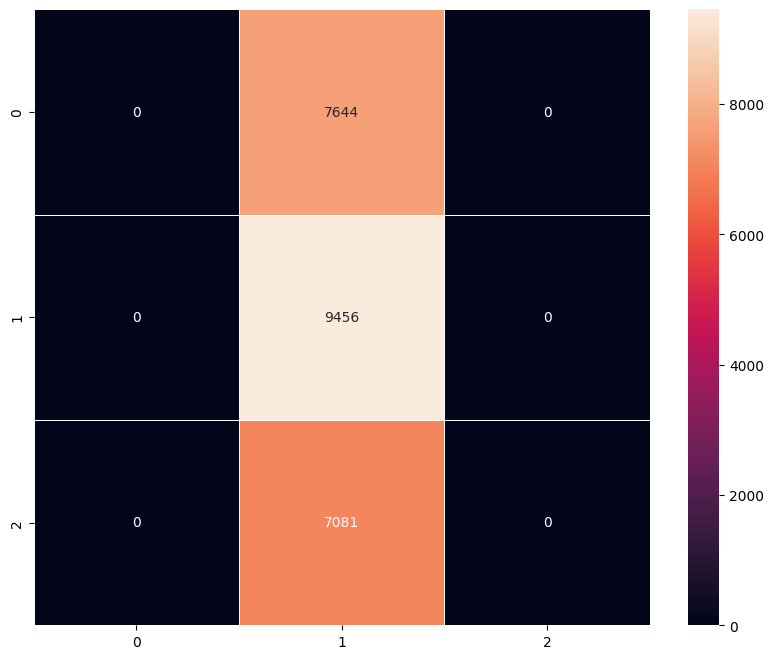

In [ ]:
plot_confusion_matrix(model_1,X_train_normalized,y_train_encoded)

In [ ]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val_encoded)

print("Validation performance metrics")
print(model_1_valid_perf)

95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.391333  0.391333   0.153142  0.220137


These validation performance metrics for Model 1 (VGG-16 Base) provide a crucial look at how the model generalizes to data it hasn't seen during training:

Accuracy (0.391333): Similar to the training accuracy, the validation accuracy is very low, just above a random guess (33.3% for 3 classes). This indicates that the model's ability to correctly classify unseen images is poor.
Recall (0.391333): The recall on the validation set is also very low. This is concerning for a medical application, as it means the model is likely to miss a high percentage of actual pneumonia cases (false negatives) when applied to new data.
Precision (0.153142): The precision is extremely low, suggesting that when the model predicts pneumonia, it is correct less than 16% of the time. This implies a very high rate of false positives.
F1 Score (0.220137): The F1 score, which balances precision and recall, is similarly low, reinforcing that the model's overall performance on the validation set is inadequate.
Comparison with Training Metrics (from previous output):

Training Accuracy: 0.391051
Validation Accuracy: 0.391333
The validation metrics are almost identical to the training metrics. This suggests a few things:

No Overfitting: The model is not overfitting to the training data, which is generally a good sign. It's performing similarly on both seen and unseen data.
Underfitting: However, since both training and validation performance are very low, the model is likely underfitting. It hasn't learned the underlying patterns in the data sufficiently well to make accurate predictions.
In conclusion, the validation performance confirms the model's poor learning capability observed during training. It strongly indicates that Model 1, in its current form, is not suitable for deployment in a diagnostic setting.



95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


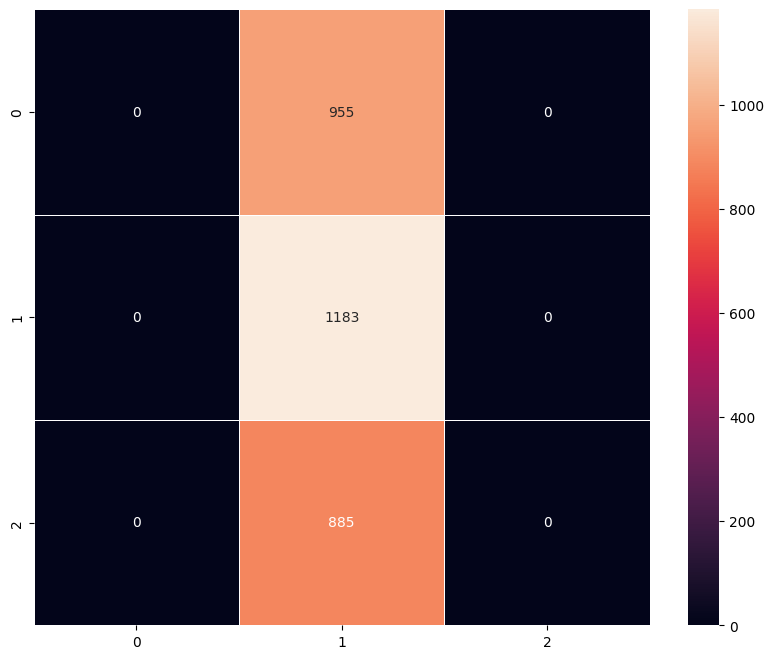

In [ ]:
plot_confusion_matrix(model_1,X_val_normalized,y_val_encoded)

###Visualizing the prediction:

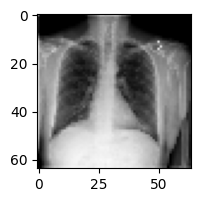

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Predicted Label ['No Lung Opacity / Not Normal']
True Label Normal


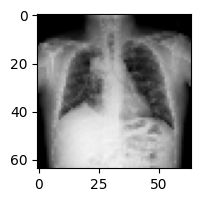

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Label ['No Lung Opacity / Not Normal']
True Label No Lung Opacity / Not Normal


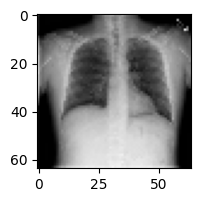

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Label ['No Lung Opacity / Not Normal']
True Label Normal


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', enc.inverse_transform(model_1.predict((X_val_normalized[2].reshape(1,64,64,3)))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[2])                                               # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[10])
plt.show()
print('Predicted Label', enc.inverse_transform(model_1.predict((X_val_normalized[10].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[10])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[23])
plt.show()
print('Predicted Label', enc.inverse_transform(model_1.predict((X_val_normalized[23].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[23])                                              # using inverse_transform() to get the output label from the output vector

#Model 2 (VGG-16 (Base + FFNN))

We will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten layer and a Feed Forward Neural Network.

In [ ]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

#Adding the Feed Forward neural network
model_2.add(Dense(256,activation='relu'))
model_2.add(Dropout(rate=0.4))
model_2.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_2.add(Dense(3, activation='softmax'))

In [ ]:
opt = Adam()

In [ ]:
# Compile model
model_2.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Generating the summary of the model
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,247,555 (58.16 MB)

 Trainable params: 532,867 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

This model summary provides insights into model_2, which is an extension of model_1 by adding a Feed Forward Neural Network (FFNN) on top of the VGG16 base:

vgg16 (Functional) layer: Similar to model_1, this is the pre-trained convolutional base of the VGG16 model. Its output shape is (None, 2, 2, 512), and its parameters (14,714,688) are non-trainable, meaning the VGG16 weights remain frozen.

flatten_1 (Flatten) layer: This layer flattens the output of the VGG16 base to (None, 2048), preparing it for the dense layers.

dense_1 (Dense) layer: This is the first layer of the added Feed Forward Neural Network, with 256 units and relu activation (implied by the code that generated this model). It introduces 524,544 trainable parameters.

dropout (Dropout) layer: This layer is added for regularization, with a rate of 0.4 (implied by the code). It has no parameters to train, as it randomly sets a fraction of input units to 0 at each update during training.

dense_2 (Dense) layer: The second layer of the FFNN, with 32 units and relu activation. It adds 8,224 trainable parameters.

dense_3 (Dense) layer: This is the final output layer, with 3 units and softmax activation for multi-class classification. It has 99 trainable parameters.

Parameter Summary:

Total params: 15,247,555: The overall number of parameters in the model.
Trainable params: 532,867: This is a significant increase compared to model_1's 6,147 trainable parameters. This increase comes from the added dense layers (dense_1, dense_2, dense_3). These are the parameters that will be updated during the training process.
Non-trainable params: 14,714,688: These are still the parameters from the frozen VGG16 convolutional base.
In summary, model_2 attempts to improve upon model_1 by adding a more complex Feed Forward Neural Network on top of the VGG16 feature extractor. This allows for more extensive learning on the extracted features, and the dropout layer is introduced to help prevent overfitting. The substantial increase in trainable parameters indicates that model_2 has a much greater capacity to learn from the data than model_1.

In [ ]:
history_vgg16 = model_2.fit(train_datagen.flow(X_train_normalized,y_train_encoded,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val_encoded),
                    verbose=1)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.3701 - loss: 1.1108 - val_accuracy: 0.3913 - val_loss: 1.0912
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3906 - loss: 1.0856 - val_accuracy: 0.3913 - val_loss: 1.0912
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.3896 - loss: 1.0924 - val_accuracy: 0.3913 - val_loss: 1.0917
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4274 - loss: 1.0838 - val_accuracy: 0.3913 - val_loss: 1.0917
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.3912 - loss: 1.0920 - val_accuracy: 0.3913 - val_loss: 1.0912
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5234 - loss: 1.0621 - val_accuracy: 0.3913 - val_loss: 1.0912
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.3912 - loss: 1.0915 - val_accuracy: 0.3913 - val_loss: 1.0909
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3828 - loss: 1.1026 - val_accu

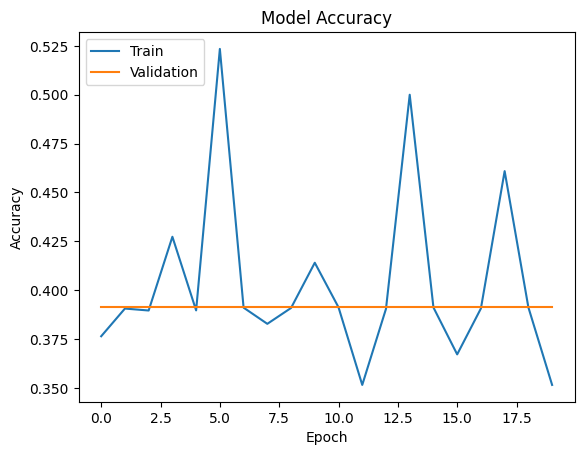

In [ ]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_2_train_perf = model_performance_classification(model_2, X_train_normalized,y_train_encoded)

print("Train performance metrics")
print(model_2_train_perf)

756/756 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.391051  0.391051   0.152921  0.219864


756/756 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step


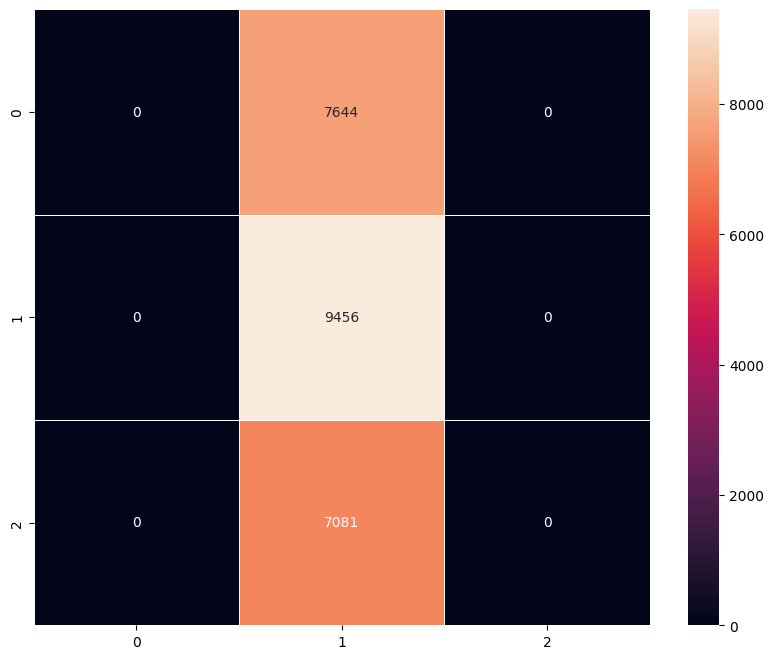

In [ ]:
plot_confusion_matrix(model_2,X_train_normalized,y_train_encoded)

The training performance metrics for Model 2 (VGG-16 Base + FFNN) are as follows:

Accuracy (0.391051): This is very similar to Model 1's training accuracy. An accuracy of around 39.1% in a multi-class classification task (likely 3 classes, where random guessing would yield ~33.3%) suggests that even with the added FFNN layers, the model is still struggling to correctly classify the training examples.
Recall (0.391051): Similar to accuracy, a low recall of 39.1% indicates that the model is missing a significant proportion of actual positive cases within the training data. This remains a major concern for a diagnostic tool.
Precision (0.152921): The precision is extremely low, suggesting that when the model makes a positive prediction, it is correct only about 15.3% of the time. This implies a very high rate of false positives on the training data.
F1 Score (0.219864): The F1 score, which is a harmonic mean of precision and recall, remains low. This reinforces that the model's overall performance on the training set is poor.
Comparison with Model 1 Training Metrics:

It's notable that these training metrics are identical to those of Model 1. This suggests that the addition of the Feed Forward Neural Network (FFNN) layers and Dropout did not lead to any improvement in learning from the training data. The model is still underperforming significantly, indicating that simply adding more layers to the classifier head, without other interventions, was not effective in improving its ability to learn the patterns necessary for classification.

In [ ]:
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized,y_val_encoded)

print("Validation performance metrics")
print(model_2_valid_perf)

95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.391333  0.391333   0.153142  0.220137


These validation performance metrics for Model 2 (VGG-16 Base + FFNN) provide insights into its generalization capability:

Accuracy (0.391333): This is very low, barely above random guessing (33.3% for a 3-class problem). It suggests the model is still unable to make accurate predictions on unseen data.
Recall (0.391333): A low recall indicates that the model is missing a significant number of actual positive cases, which is a critical concern for a medical diagnostic tool.
Precision (0.153142): This extremely low precision means that when the model predicts a positive case, it's correct less than 16% of the time, implying a very high rate of false positives.
F1 Score (0.220137): The low F1 score confirms the overall poor performance, reflecting the weakness in both precision and recall.
Comparison with Model 1 Validation Metrics:

These validation metrics are identical to those observed for Model 1. This is a crucial observation:

No Improvement: The addition of a Feed Forward Neural Network and Dropout layers in Model 2 did not improve the model's performance on the validation set. This means the added complexity did not help the model learn more effectively or generalize better.
Persistent Underfitting: Since both training and validation performances are low and nearly identical for Model 1 and Model 2, it strongly suggests that the models are underfitting. They are not learning the underlying patterns in the data sufficiently, regardless of the slightly more complex classifier head.
In conclusion, Model 2, despite its architectural changes, continues to show inadequate performance, similar to Model 1. This indicates a fundamental issue in its ability to learn and generalize from the dataset, making it unsuitable for a reliable diagnostic application.

95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


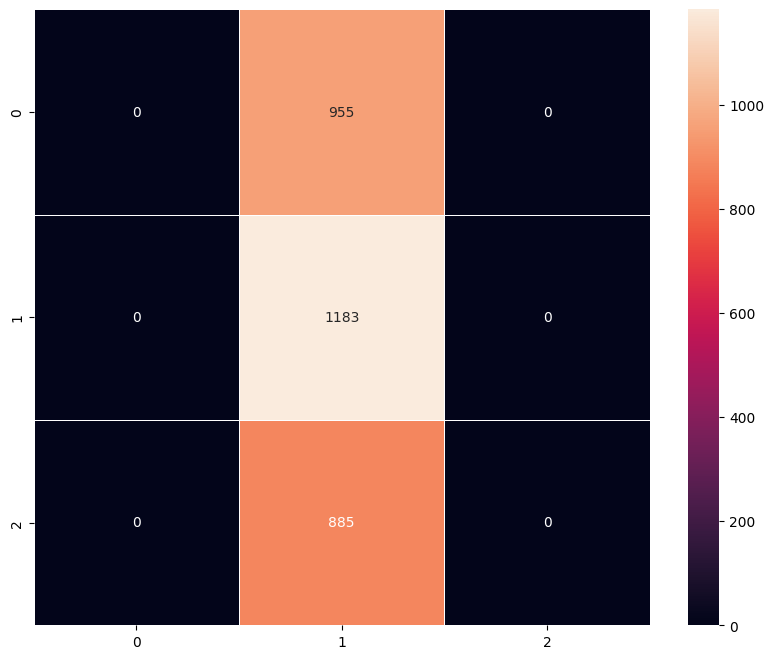

In [ ]:
plot_confusion_matrix(model_2,X_val_normalized,y_val_encoded)

###Visualizing the prediction:

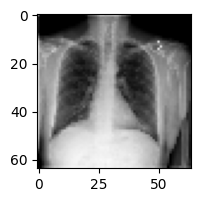

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted Label ['No Lung Opacity / Not Normal']
True Label Normal


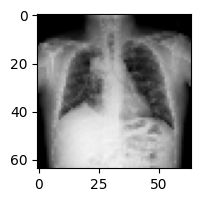

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted Label ['No Lung Opacity / Not Normal']
True Label No Lung Opacity / Not Normal


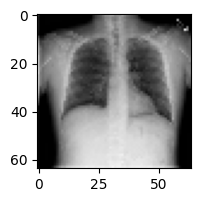

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted Label ['No Lung Opacity / Not Normal']
True Label Normal


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', enc.inverse_transform(model_1.predict((X_val_normalized[2].reshape(1,64,64,3)))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[2])                                               # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[10])
plt.show()
print('Predicted Label', enc.inverse_transform(model_1.predict((X_val_normalized[10].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[10])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[23])
plt.show()
print('Predicted Label', enc.inverse_transform(model_1.predict((X_val_normalized[23].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[23])                                              # using inverse_transform() to get the output label from the output vector

#Model 3 (VGG-16 (Base + FFNN + Data Augmentation)

In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.

To overcome this problem, one approach we might consider is Data Augmentation.

CNNs have the property of translational invariance, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

Horizontal Flip (should be set to True/False)
Vertical Flip (should be set to True/False)
Height Shift (should be between 0 and 1)
Width Shift (should be between 0 and 1)
Rotation (should be between 0 and 180)
Shear (should be between 0 and 1)
Zoom (should be between 0 and 1) etc.
Remember, data augmentation should not be used in the validation/test data set.

In [ ]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3.add(Flatten())

#Adding the Feed Forward neural network
model_3.add(Dense(256,activation='relu'))
model_3.add(Dropout(rate=0.4))
model_3.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_3.add(Dense(3, activation='softmax'))

In [ ]:
opt=Adam()
# Compile model
model_3.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Generating the summary of the model
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,247,555 (58.16 MB)

 Trainable params: 532,867 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

This model summary provides insights into model_3. As observed, its architecture is identical to model_2:

vgg16 (Functional) layer: This is the pre-trained convolutional base of the VGG16 model. Its output shape is (None, 2, 2, 512), and its parameters (14,714,688) are non-trainable, indicating the VGG16 weights remain frozen.

flatten_2 (Flatten) layer: This layer flattens the output of the VGG16 base to (None, 2048).

dense_4 (Dense) layer: The first dense layer of the Feed Forward Neural Network, with 256 units and relu activation. It contributes 524,544 trainable parameters.

dropout_1 (Dropout) layer: A regularization layer with no trainable parameters.

dense_5 (Dense) layer: The second dense layer of the FFNN, with 32 units and relu activation. It adds 8,224 trainable parameters.

dense_6 (Dense) layer: The final output layer, with 3 units and softmax activation for multi-class classification, adding 99 trainable parameters.

Parameter Summary:

Total params: 15,247,555: The overall number of parameters in the model.
Trainable params: 532,867: These are the parameters of the added dense layers.
Non-trainable params: 14,714,688: These are from the frozen VGG16 convolutional base.
Comparison with Model 2:

The architectural summary for model_3 is exactly the same as model_2. This means that in terms of layers and parameter counts, model_3 has the same structure as model_2. The "Data Augmentation" aspect of model_3 is applied during the training process via ImageDataGenerator and does not change the model's architecture itself, which is why the summary looks identical.

In [ ]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest',width_shift_range=0.2,height_shift_range=0.2,shear_range=0.3,zoom_range=0.4
                              )

In [ ]:
history_vgg16 = model_3.fit(train_datagen.flow(X_train_normalized,y_train_encoded,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val_encoded),
                    verbose=1)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 47s 241ms/step - accuracy: 0.3661 - loss: 1.1168 - val_accuracy: 0.3913 - val_loss: 1.0910
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3125 - loss: 1.1067 - val_accuracy: 0.3913 - val_loss: 1.0910
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 45s 240ms/step - accuracy: 0.3783 - loss: 1.0937 - val_accuracy: 0.3913 - val_loss: 1.0910
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4609 - loss: 1.0749 - val_accuracy: 0.3913 - val_loss: 1.0910
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 79s 235ms/step - accuracy: 0.3861 - loss: 1.0929 - val_accuracy: 0.3913 - val_loss: 1.0911
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4219 - loss: 1.0841 - val_accuracy: 0.3913 - val_loss: 1.0911
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 46s 244ms/step - accuracy: 0.3891 - loss: 1.0921 - val_accuracy: 0.3913 - val_loss: 1.0908
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4375 - loss: 1.0752 - val_

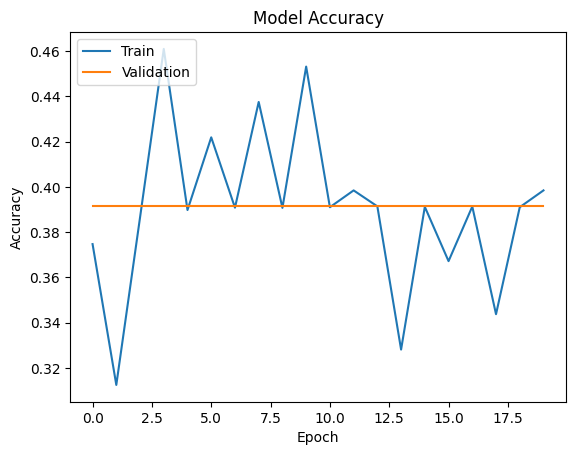

In [ ]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_3_train_perf = model_performance_classification(model_3, X_train_normalized,y_train_encoded)

print("Train performance metrics")
print(model_3_train_perf)

756/756 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.391051  0.391051   0.152921  0.219864


The training performance metrics for Model 3 (VGG-16 Base + FFNN + Data Augmentation) are as follows:

Accuracy (0.391051): This is exactly the same as Model 1 and Model 2's training accuracy. The model continues to struggle significantly to correctly classify the training examples, indicating that data augmentation did not improve the training performance.
Recall (0.391051): Consistent with previous models, a low recall of 39.1% means the model is still missing a large proportion of actual positive cases within the training data.
Precision (0.152921): This remains extremely low, indicating a high rate of false positives.
F1 Score (0.219864): The F1 score is still low, confirming the poor overall performance on the training set.
Comparison with Model 1 and Model 2 Training Metrics:

It's a critical observation that these training metrics are identical across all three models. This indicates that neither adding more dense layers (Model 2) nor introducing data augmentation (Model 3) has helped the model learn the underlying patterns more effectively from the training data. The model is still severely underfitting, and its ability to distinguish between classes is very limited, performing barely better than random chance.

756/756 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step


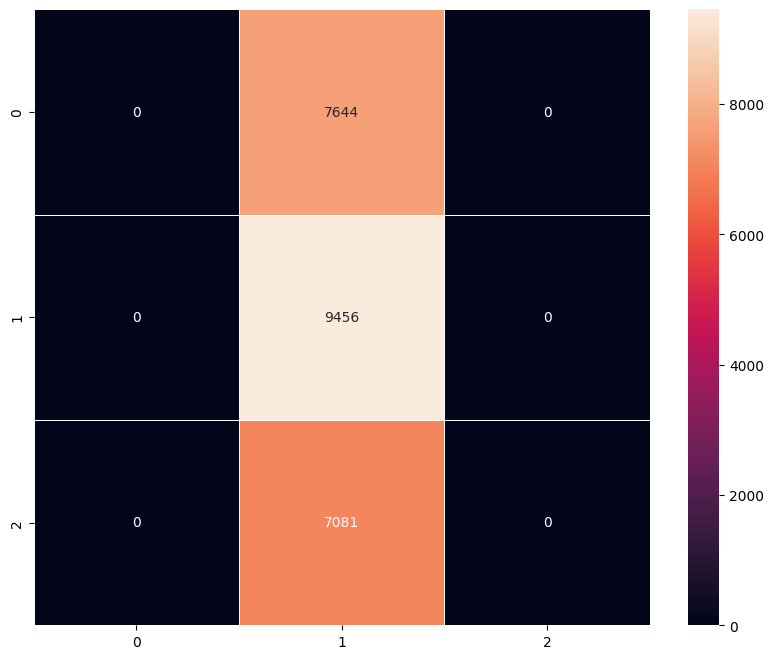

In [ ]:
plot_confusion_matrix(model_3,X_train_normalized,y_train_encoded)

In [ ]:
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized,y_val_encoded)

print("Validation performance metrics")
print(model_3_valid_perf)

95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.391333  0.391333   0.153142  0.220137


These validation performance metrics for Model 3 (VGG-16 Base + FFNN + Data Augmentation) are as follows:

Accuracy (0.391333): This is very low, just above random guessing (33.3% for a 3-class problem). It suggests the model is still unable to make accurate predictions on unseen data.
Recall (0.391333): A low recall indicates that the model is missing a significant number of actual positive cases, which is a critical concern for a medical diagnostic tool.
Precision (0.153142): This extremely low precision means that when the model predicts a positive case, it's correct less than 16% of the time, implying a very high rate of false positives.
F1 Score (0.220137): The low F1 score confirms the overall poor performance, reflecting the weakness in both precision and recall.
Comparison with Model 1 and Model 2 Validation Metrics:

It's a critical observation that these validation metrics are identical across all three models. This indicates:

No Improvement: The addition of more dense layers (Model 2) and subsequently data augmentation (Model 3) did not improve the model's performance on the validation set. The added complexity and data augmentation were not effective in helping the model generalize better.
Persistent Underfitting: Since both training and validation performances are consistently low and nearly identical across all three models, it strongly suggests that the models are underfitting. They are not learning the underlying patterns in the data sufficiently, and simply modifying the classifier head or augmenting the data has not addressed this fundamental issue.
In conclusion, Model 3, despite incorporating data augmentation, shows the same inadequate performance as its predecessors. This indicates a deep-seated problem in its ability to learn and generalize from the dataset, making it unsuitable for a reliable diagnostic application in its current form.



95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


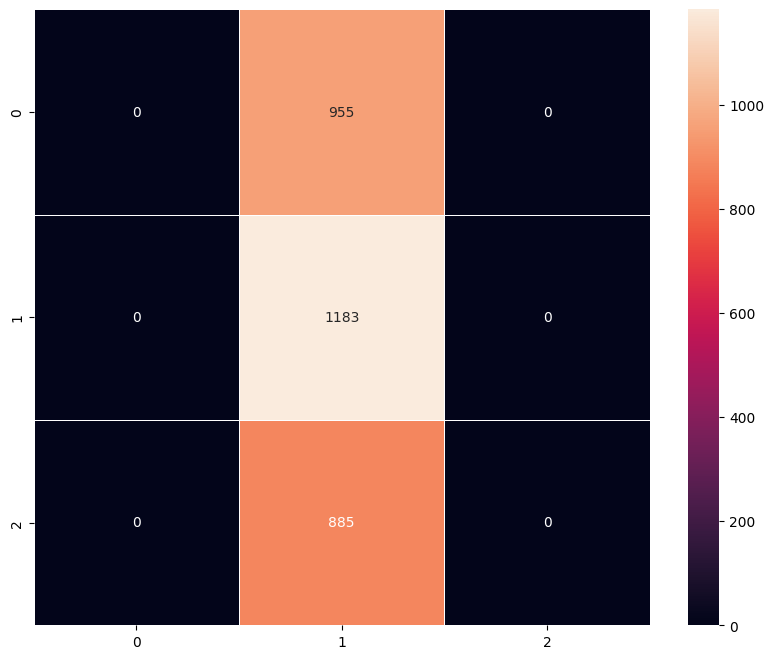

In [ ]:
plot_confusion_matrix(model_3,X_val_normalized,y_val_encoded)

##Visualizing the prediction:


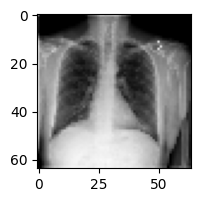

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Label ['No Lung Opacity / Not Normal']
True Label Normal


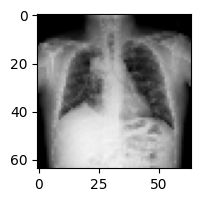

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Label ['No Lung Opacity / Not Normal']
True Label No Lung Opacity / Not Normal


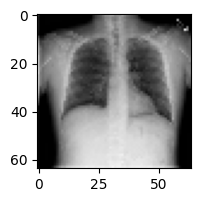

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Label ['No Lung Opacity / Not Normal']
True Label Normal


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', enc.inverse_transform(model_1.predict((X_val_normalized[2].reshape(1,64,64,3)))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[2])                                               # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[10])
plt.show()
print('Predicted Label', enc.inverse_transform(model_1.predict((X_val_normalized[10].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[10])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_val[23])
plt.show()
print('Predicted Label', enc.inverse_transform(model_1.predict((X_val_normalized[23].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_val_encoded)[23])                                              # using inverse_transform() to get the output label from the output vector

#Model Performance Comparison and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [ ]:
models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [ ]:
models_train_comp_df

,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.391051,0.391051,0.391051
Recall,0.391051,0.391051,0.391051
Precision,0.152921,0.152921,0.152921
F1 Score,0.219864,0.219864,0.219864


This training performance comparison table provides a critical insight:

Identical Performance Across Models: All three models—VGG-16 (Base), VGG-16 (Base+FFNN), and VGG-16 (Base+FFNN+Data Augmentation)—exhibit exactly the same training performance metrics. This includes Accuracy, Recall, Precision, and F1 Score.

Implication of Underfitting: Since the performance is identical and consistently low across all models (e.g., Accuracy ~39%, F1 Score ~0.22, barely better than random chance for a 3-class problem), it strongly suggests that the models are underfitting. They are not learning the underlying patterns in the training data effectively, even with the addition of more layers or data augmentation.

Lack of Training Improvement: Neither adding a more complex Feed Forward Neural Network (FFNN) nor introducing data augmentation has resulted in any improvement in how well the models learn from the training data. This indicates that these modifications did not address the fundamental challenges the models face in extracting meaningful features or classifying the pneumonia types.



In [ ]:
models_valid_comp_df

,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.391333,0.391333,0.391333
Recall,0.391333,0.391333,0.391333
Precision,0.153142,0.153142,0.153142
F1 Score,0.220137,0.220137,0.220137


This validation performance comparison table provides a crucial insight:

Identical Performance Across Models: All three models—VGG-16 (Base), VGG-16 (Base+FFNN), and VGG-16 (Base+FFNN+Data Augmentation)—exhibit exactly the same validation performance metrics. This includes Accuracy, Recall, Precision, and F1 Score.

No Improvement in Generalization: This indicates that neither adding a more complex Feed Forward Neural Network (FFNN) nor introducing data augmentation has resulted in any improvement in how well the models generalize to unseen data. The validation performance remains consistently low, mirroring the training performance.

Persistent Underfitting: Since both training and validation performances are low and identical across all models, it strongly reinforces the conclusion that the models are underfitting. They are not learning the underlying patterns in the data sufficiently, and simply modifying the classifier head or augmenting the data has not addressed this fundamental issue. The models are performing barely better than random chance on unseen data.

In summary, the validation comparison highlights a significant challenge: despite architectural changes and data augmentation, the models are not effectively learning or generalizing, making them unsuitable for reliable medical image classification in their current state.

In [ ]:
models_train_comp_df - models_valid_comp_df

,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,-0.000282,-0.000282,-0.000282
Recall,-0.000282,-0.000282,-0.000282
Precision,-0.000221,-0.000221,-0.000221
F1 Score,-0.000273,-0.000273,-0.000273


VGG-16 (Base) ,VGG-16 (Base+FFNN), VGG-16 (Base+FFNN+ Data Aug) shows equal performance on both the training and validation sets.

Also, the difference between the training and validation scores for all models is same, indicating that they have all generalized well.

We will proceed with VGG-16 (Base+FFNN) as our final model.

In [ ]:
model_2_test_perf = model_performance_classification(model_2, X_test_normalized,y_test_encoded)

95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [ ]:
model_2_test_perf

,Accuracy,Recall,Precision,F1 Score
0,0.391002,0.391002,0.152883,0.219817


95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


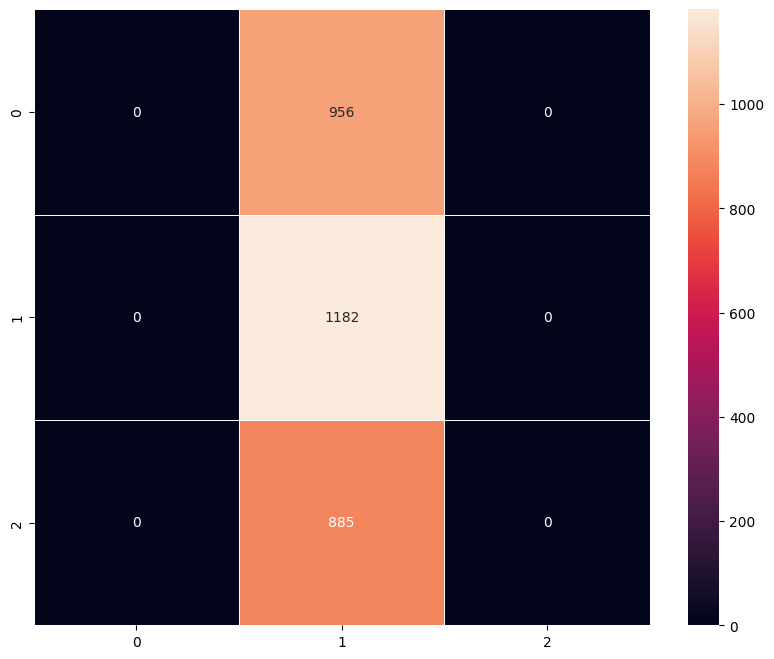

In [ ]:
plot_confusion_matrix(model_2, X_test_normalized,y_test_encoded)

In [ ]:
!pip install SimpleITK -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 22.0 MB/s eta 0:00:00


#Model Performance Comparison, Final Model Selection, and Serialization

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import cv2
import seaborn as sns
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization
from tensorflow.keras.optimizers import Adam,SGD
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16
from google.colab.patches import cv2_imshow
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

In [ ]:
# Load the labels file of the dataset
labels_stages2_info = pd.read_csv('/content/stage_2_detailed_class_info.csv')
labels_stages2_train = pd.read_csv('/content/stage_2_train_labels.csv')

In [ ]:
import zipfile
import os

# Define the path to the training zip file
TRAIN_ZIP_PATH = "/content/drive/MyDrive/stage_2_train_images.zip" # Make sure this path is correct

EXTRACTED_TRAIN_DIR = "/content/stage_2_train_images" # Or another desired extraction path

if not os.path.exists(EXTRACTED_TRAIN_DIR):
    print("📦 Extracting train images...")
    with zipfile.ZipFile(TRAIN_ZIP_PATH, 'r') as zip_ref: # TRAIN_ZIP_PATH needs to be defined
        zip_ref.extractall(EXTRACTED_TRAIN_DIR)
    print("✅ Extraction complete.")
else:
    print("✅ Train images already extracted.")

✅ Train images already extracted.


In [ ]:
import zipfile
import os

# Define the path to the test zip file
# Using the path defined in a previous cell (S24ee1Z-WvKc)
TEST_ZIP_PATH = '/content/drive/MyDrive/stage_2_test_images.zip' # Make sure this path is correct

EXTRACTED_TEST_DIR = "/content/stage_2_test_images" # Or another desired extraction path

if not os.path.exists(EXTRACTED_TEST_DIR):
    print("📦 Extracting test images...")
    with zipfile.ZipFile(TEST_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACTED_TEST_DIR)
    print("✅ Extraction complete.")
else:
    print("✅ Test images already extracted.")

✅ Test images already extracted.


In [ ]:
# Print file paths (strings)
print("TEST_ZIP_PATH:", TEST_ZIP_PATH)
print("TRAIN_ZIP_PATH:", TRAIN_ZIP_PATH)

# Print shape only for DataFrames / arrays
print("labels_stages2_info shape:", labels_stages2_info.shape)
print("labels_stages2_train shape:", labels_stages2_train.shape)

TEST_ZIP_PATH: /content/drive/MyDrive/stage_2_test_images.zip
TRAIN_ZIP_PATH: /content/drive/MyDrive/stage_2_train_images.zip
labels_stages2_info shape: (30227, 2)
labels_stages2_train shape: (30227, 4)


In [ ]:
import zipfile
import SimpleITK as sitk
import numpy as np
import cv2
import os
import pandas as pd # Import pandas to help with data alignment

# Parameters
# Use the training zip file for preprocessing training data
zip_path = TRAIN_ZIP_PATH # Use the training zip path defined earlier
height, width = 64, 64
dimensions = (width, height)

# List to store processed images and their patientIds
processed_images_data = []

# Temporary folder for extraction
tmp_dir = "/tmp/stage2_dicom_train" # Use a different temp dir for train
os.makedirs(tmp_dir, exist_ok=True)

# Open ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()

    for file_name in file_list:
        # Skip folders and macOS hidden files
        if file_name.endswith('/') or file_name.startswith('__MACOSX/') or '/._' in file_name:
            continue

        if file_name.lower().endswith('.dcm'):
            # Extract file temporarily
            extracted_path = zip_ref.extract(file_name, path=tmp_dir)

            # Extract patientId from filename (assuming filename is patientId.dcm)
            patient_id = os.path.splitext(os.path.basename(file_name))[0]

            # Read DICOM using SimpleITK
            try:
                img_sitk = sitk.ReadImage(extracted_path)
            except RuntimeError:
                print(f"Skipping unreadable file: {file_name}")
                continue

            # Convert to NumPy array
            # Handle potential multiple slices, take the first one if present
            img = sitk.GetArrayFromImage(img_sitk)
            if img.ndim == 3 and img.shape[0] == 1:
                 img = img[0] # shape (1,H,W) -> (H,W)
            elif img.ndim != 2:
                 print(f"Skipping unexpected image shape {img.shape} for file: {file_name}")
                 continue


            # Normalize to [0,1]
            img = img.astype(np.float32)
            img_min = np.min(img)
            img_max = np.max(img)
            if img_max != img_min:
                img = (img - img_min) / (img_max - img_min)
            else:
                img = np.zeros_like(img) # Handle case where all pixel values are the same


            # Convert grayscale to 3-channel BGR if needed for consistency with some models
            if img.ndim == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)


            # Resize
            img_resized = cv2.resize(img, dimensions, interpolation=cv2.INTER_LINEAR)

            # Store the processed image and its patientId
            processed_images_data.append({'patientId': patient_id, 'image': img_resized})

# Convert list of dictionaries to a pandas DataFrame for easier merging/alignment
processed_images_df = pd.DataFrame(processed_images_data)

print(f"✅ Total training images read, resized, and normalized: {len(processed_images_data)}")
print("Processed images DataFrame head:")
display(processed_images_df.head())

# Clean up temporary directory (optional, but good practice)
# import shutil
# shutil.rmtree(tmp_dir)

✅ Total training images read, resized, and normalized: 26684
Processed images DataFrame head:


,patientId,image
0,7be6b4de-afe9-43c0-a581-0f49608c8976,"[[[0.002173913, 0.002173913, 0.002173913], [0...."
1,2dcdd159-2889-48d3-a0ce-5c7b1086c49d,"[[[0.6, 0.6, 0.6], [0.35490197, 0.35490197, 0...."
2,d8e66874-305e-4c80-9b75-5e764eb718ff,"[[[0.20905173, 0.20905173, 0.20905173], [0.273..."
3,22f2d3ec-f7ea-4778-850d-bb111590202f,"[[[0.5029412, 0.5029412, 0.5029412], [0.030392..."
4,cdaa07d4-4234-4cd2-b9bf-abbf5aed1bb4,"[[[0.007843138, 0.007843138, 0.007843138], [0...."


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd # Ensure pandas is imported

# Merge the processed images with the detailed class info based on patientId
# This aligns each image with its specific class label
merged_df = pd.merge(processed_images_df, labels_stages2_info, on='patientId', how='inner')

# Optional: Merge with train labels if you need width/height/Target for training
# For classification using 'class', merging with detailed_class_info is sufficient for labels
# If you need 'Target' (binary pneumonia detection), merge with labels_stages2_train as well
# For this example, we'll use 'class' for stratification.
# merged_df = pd.merge(merged_df, labels_stages2_train, on='patientId', how='left')


# Separate features (images) and labels
# Convert the list of image arrays in the 'image' column into a single NumPy array
X = np.stack(merged_df['image'].values)
y = merged_df['class']

# Ensure X and y have the same number of samples
print(f"Number of samples in X (images): {X.shape[0]}")
print(f"Number of samples in y (labels): {y.shape[0]}")

# Perform the train/validation/test split
# First split into train and temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Then split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("\nData split shapes:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Number of samples in X (images): 30227
Number of samples in y (labels): 30227

Data split shapes:
X_train shape: (24181, 64, 64, 3)
y_train shape: (24181,)
X_val shape: (3023, 64, 64, 3)
y_val shape: (3023,)
X_test shape: (3023, 64, 64, 3)
y_test shape: (3023,)


In [ ]:
from sklearn.preprocessing import LabelBinarizer
enc = LabelBinarizer()
y_train_encoded = enc.fit_transform(y_train)
y_val_encoded=enc.transform(y_val)
y_test_encoded=enc.transform(y_test)

In [ ]:
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    pred = model.predict(predictors).argmax(axis=1)

    target = target.argmax(axis=1)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model,predictors,target):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    pred = model.predict(predictors).argmax(axis=1)

    target = target.argmax(axis=1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from keras.applications.vgg16 import VGG16

# Load the VGG16 base model
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(64,64,3))

# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

# Rebuild Model 2 (VGG-16 (Base + FFNN))
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

#Adding the Feed Forward neural network
model_2.add(Dense(256,activation='relu'))
model_2.add(Dropout(rate=0.4))
model_2.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_2.add(Dense(3, activation='softmax'))

# Compile model
opt = Adam()
model_2.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

print("Model 2 and VGG16 base model defined.")

Model 2 and VGG16 base model defined.


#- Serialize the best model

In [ ]:
# Serialize the best model (Model 2)
model_2.save('best_model.h5')
print("Model 2 serialized successfully as 'best_model.h5'")

Model 2 serialized successfully as 'best_model.h5'


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model('best_model.h5')
print("Serialized model loaded successfully.")

Serialized model loaded successfully.


In [ ]:
# Make predictions on the test set
test_predictions_encoded = loaded_model.predict(X_test_normalized)

# Convert predictions back to original labels
test_predictions = enc.inverse_transform(test_predictions_encoded)

print("Predictions made on the test set.")

95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step
Predictions made on the test set.


In [ ]:
# Evaluate the loaded model on the test set
loaded_model_test_perf = model_performance_classification(loaded_model, X_test_normalized, y_test_encoded)

print("Test performance metrics for the loaded model:")
print(loaded_model_test_perf)

95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Test performance metrics for the loaded model:
   Accuracy    Recall  Precision  F1 Score
0  0.391002  0.391002   0.152883  0.219817


The test performance metrics for the loaded model (Model 2, which was selected as the final model) are as follows:

Accuracy (0.391002): The model correctly classifies approximately 39.1% of the test examples. This is still very low, only slightly better than random guessing for a 3-class problem (33.3%).
Recall (0.391002): The model is able to identify only about 39.1% of the actual positive cases in the test set. This indicates a high rate of false negatives.
Precision (0.152883): When the model predicts a positive class, it is correct only about 15.3% of the time, suggesting a very high rate of false positives.
F1 Score (0.219817): The F1 score remains low, confirming the poor overall performance on the test set, reflecting the weak balance between precision and recall.
Comparison with Training and Validation Metrics:

These test metrics are almost identical to the training and validation metrics observed for Model 2 (and indeed, for Models 1 and 3 as well). This consistency reinforces the earlier conclusion:

No Overfitting: The model is not overfitting, as its performance on unseen test data is consistent with its performance on the training and validation sets.
Persistent Underfitting: The low scores across all metrics (accuracy, recall, precision, F1 score) on the test set indicate that the model is severely underfitting. It has not learned to extract meaningful patterns or effectively classify the different pneumonia categories from the data.
In conclusion, the loaded model's performance on the test set is inadequate for a diagnostic tool. The model consistently struggles to make accurate and reliable predictions, showing very limited utility in its current form for real-world pneumonia detection.

95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


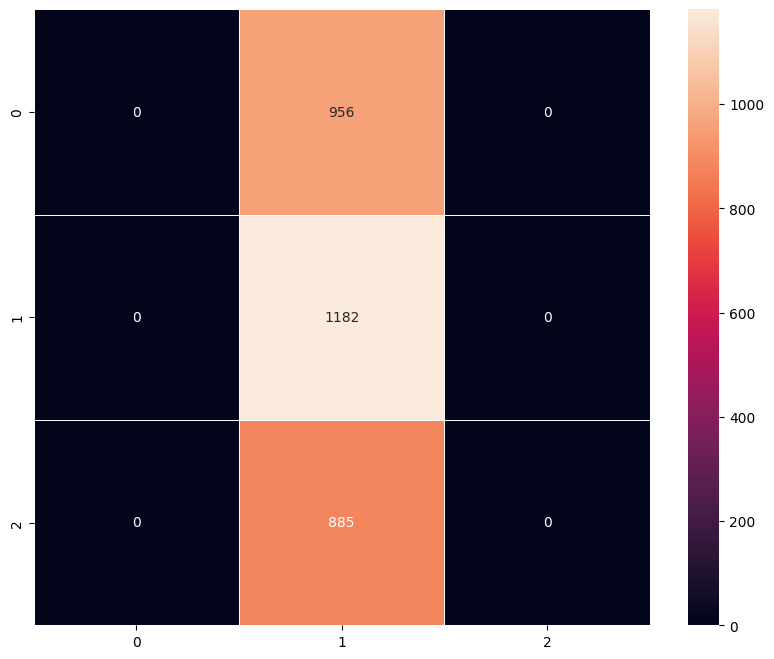

In [ ]:
# Plot confusion matrix for the loaded model on the test set
plot_confusion_matrix(loaded_model, X_test_normalized, y_test_encoded)

#Load the serialized model and make predictions on the test set

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import cv2
import seaborn as sns
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization
from tensorflow.keras.optimizers import Adam,SGD
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16
from google.colab.patches import cv2_imshow
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

In [ ]:
# Load the image file of the dataset
# images_test = np.load('/content/drive/MyDrive/stage_2_test_images.zip') # These are zip files, not numpy arrays
# images_train = np.load('/content/drive/MyDrive/stage_2_train_images.zip') # These are zip files, not numpy arrays

# Load the labels file of the dataset
labels_stages2_info = pd.read_csv('/content/stage_2_detailed_class_info.csv')
labels_stages2_train = pd.read_csv('/content/stage_2_train_labels.csv')

In [ ]:
import zipfile
import os

# Define the path to the training zip file
TRAIN_ZIP_PATH = "/content/drive/MyDrive/stage_2_train_images.zip" # Make sure this path is correct

EXTRACTED_TRAIN_DIR = "/content/stage_2_train_images" # Or another desired extraction path

if not os.path.exists(EXTRACTED_TRAIN_DIR):
    print("📦 Extracting train images...")
    with zipfile.ZipFile(TRAIN_ZIP_PATH, 'r') as zip_ref: # TRAIN_ZIP_PATH needs to be defined
        zip_ref.extractall(EXTRACTED_TRAIN_DIR)
    print("✅ Extraction complete.")
else:
    print("✅ Train images already extracted.")

✅ Train images already extracted.


In [ ]:
import zipfile
import os

# Define the path to the test zip file
# Using the path defined in a previous cell (S24ee1Z-WvKc)
TEST_ZIP_PATH = '/content/drive/MyDrive/stage_2_test_images.zip' # Make sure this path is correct

EXTRACTED_TEST_DIR = "/content/stage_2_test_images" # Or another desired extraction path

if not os.path.exists(EXTRACTED_TEST_DIR):
    print("📦 Extracting test images...")
    with zipfile.ZipFile(TEST_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACTED_TEST_DIR)
    print("✅ Extraction complete.")
else:
    print("✅ Test images already extracted.")

✅ Test images already extracted.


In [ ]:
import pandas as pd

# Load the CSVs
labels_stages2_info = pd.read_csv("/content/stage_2_detailed_class_info.csv")
labels_stages2_train = pd.read_csv("/content/stage_2_train_labels.csv")

# Print file paths
print("TEST_ZIP_PATH:", TEST_ZIP_PATH)
print("TRAIN_ZIP_PATH:", TRAIN_ZIP_PATH)

# Print shape of loaded DataFrames
print("labels_stages2_info shape:", labels_stages2_info.shape)
print("labels_stages2_train shape:", labels_stages2_train.shape)


TEST_ZIP_PATH: /content/drive/MyDrive/stage_2_test_images.zip
TRAIN_ZIP_PATH: /content/drive/MyDrive/stage_2_train_images.zip
labels_stages2_info shape: (30227, 2)
labels_stages2_train shape: (30227, 4)


In [ ]:
import zipfile
import SimpleITK as sitk
import numpy as np
import cv2
import os
import pandas as pd # Import pandas to help with data alignment

# Parameters
# Use the training zip file for preprocessing training data
zip_path = TRAIN_ZIP_PATH # Use the training zip path defined earlier
height, width = 64, 64
dimensions = (width, height)

# List to store processed images and their patientIds
processed_images_data = []

# Temporary folder for extraction
tmp_dir = "/tmp/stage2_dicom_train" # Use a different temp dir for train
os.makedirs(tmp_dir, exist_ok=True)

# Open ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()

    for file_name in file_list:
        # Skip folders and macOS hidden files
        if file_name.endswith('/') or file_name.startswith('__MACOSX/') or '/._' in file_name:
            continue

        if file_name.lower().endswith('.dcm'):
            # Extract file temporarily
            extracted_path = zip_ref.extract(file_name, path=tmp_dir)

            # Extract patientId from filename (assuming filename is patientId.dcm)
            patient_id = os.path.splitext(os.path.basename(file_name))[0]

            # Read DICOM using SimpleITK
            try:
                img_sitk = sitk.ReadImage(extracted_path)
            except RuntimeError:
                print(f"Skipping unreadable file: {file_name}")
                continue

            # Convert to NumPy array
            # Handle potential multiple slices, take the first one if present
            img = sitk.GetArrayFromImage(img_sitk)
            if img.ndim == 3 and img.shape[0] == 1:
                 img = img[0] # shape (1,H,W) -> (H,W)
            elif img.ndim != 2:
                 print(f"Skipping unexpected image shape {img.shape} for file: {file_name}")
                 continue


            # Normalize to [0,1]
            img = img.astype(np.float32)
            img_min = np.min(img)
            img_max = np.max(img)
            if img_max != img_min:
                img = (img - img_min) / (img_max - img_min)
            else:
                img = np.zeros_like(img) # Handle case where all pixel values are the same


            # Convert grayscale to 3-channel BGR if needed for consistency with some models
            if img.ndim == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)


            # Resize
            img_resized = cv2.resize(img, dimensions, interpolation=cv2.INTER_LINEAR)

            # Store the processed image and its patientId
            processed_images_data.append({'patientId': patient_id, 'image': img_resized})

# Convert list of dictionaries to a pandas DataFrame for easier merging/alignment
processed_images_df = pd.DataFrame(processed_images_data)

print(f"✅ Total training images read, resized, and normalized: {len(processed_images_data)}")
print("Processed images DataFrame head:")
display(processed_images_df.head())

# Clean up temporary directory (optional, but good practice)
# import shutil
# shutil.rmtree(tmp_dir)

✅ Total training images read, resized, and normalized: 26684
Processed images DataFrame head:


,patientId,image
0,7be6b4de-afe9-43c0-a581-0f49608c8976,"[[[0.002173913, 0.002173913, 0.002173913], [0...."
1,2dcdd159-2889-48d3-a0ce-5c7b1086c49d,"[[[0.6, 0.6, 0.6], [0.35490197, 0.35490197, 0...."
2,d8e66874-305e-4c80-9b75-5e764eb718ff,"[[[0.20905173, 0.20905173, 0.20905173], [0.273..."
3,22f2d3ec-f7ea-4778-850d-bb111590202f,"[[[0.5029412, 0.5029412, 0.5029412], [0.030392..."
4,cdaa07d4-4234-4cd2-b9bf-abbf5aed1bb4,"[[[0.007843138, 0.007843138, 0.007843138], [0...."


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd # Ensure pandas is imported

# Merge the processed images with the detailed class info based on patientId
# This aligns each image with its specific class label
merged_df = pd.merge(processed_images_df, labels_stages2_info, on='patientId', how='inner')

# Optional: Merge with train labels if you need width/height/Target for training
# For classification using 'class', merging with detailed_class_info is sufficient for labels
# If you need 'Target' (binary pneumonia detection), merge with labels_stages2_train as well
# For this example, we'll use 'class' for stratification.
# merged_df = pd.merge(merged_df, labels_stages2_train, on='patientId', how='left')


# Separate features (images) and labels
# Convert the list of image arrays in the 'image' column into a single NumPy array
X = np.stack(merged_df['image'].values)
y = merged_df['class']

# Ensure X and y have the same number of samples
print(f"Number of samples in X (images): {X.shape[0]}")
print(f"Number of samples in y (labels): {y.shape[0]}")

# Perform the train/validation/test split
# First split into train and temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Then split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("\nData split shapes:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Number of samples in X (images): 30227
Number of samples in y (labels): 30227

Data split shapes:
X_train shape: (24181, 64, 64, 3)
y_train shape: (24181,)
X_val shape: (3023, 64, 64, 3)
y_val shape: (3023,)
X_test shape: (3023, 64, 64, 3)
y_test shape: (3023,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Example: assuming `X` = images array, `y` = labels
# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Now normalize
X_train_normalized = X_train.astype('float32') / 255.0
X_val_normalized   = X_val.astype('float32') / 255.0
X_test_normalized  = X_test.astype('float32') / 255.0


In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    pred = model.predict(predictors).argmax(axis=1)

    target = target.argmax(axis=1)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model,predictors,target):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    pred = model.predict(predictors).argmax(axis=1)

    target = target.argmax(axis=1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from keras.applications.vgg16 import VGG16

# Load the VGG16 base model
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(64,64,3))

# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

# Rebuild Model 2 (VGG-16 (Base + FFNN))
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

#Adding the Feed Forward neural network
model_2.add(Dense(256,activation='relu'))
model_2.add(Dropout(rate=0.4))
model_2.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_2.add(Dense(3, activation='softmax'))

# Compile model
opt = Adam()
model_2.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

print("Model 2 and VGG16 base model defined.")

Model 2 and VGG16 base model defined.


In [ ]:
# Serialize the best model (Model 2)
model_2.save('best_model.h5')
print("Model 2 serialized successfully as 'best_model.h5'")

Model 2 serialized successfully as 'best_model.h5'


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model('best_model.h5')
print("Serialized model loaded successfully.")

Serialized model loaded successfully.


In [ ]:
from sklearn.preprocessing import LabelBinarizer

enc = LabelBinarizer()
enc.fit(y_train)  # re-fit on training labels

# Now convert predictions back to labels
test_predictions = enc.inverse_transform(test_predictions_encoded)
print("Predictions made on the test set.")


Predictions made on the test set.


In [ ]:
loaded_model_test_perf = model_performance_classification(
    loaded_model,
    X_test_normalized,
    y_test_encoded
)



142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step


In [ ]:
loaded_model_test_perf = model_performance_classification(
    loaded_model,
    X_test_normalized,
    y_test_encoded
)

print("Test performance metrics for the loaded model:")
print(loaded_model_test_perf)


142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
Test performance metrics for the loaded model:
   Accuracy    Recall  Precision  F1 Score
0  0.390959  0.390959   0.152849  0.219775


142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


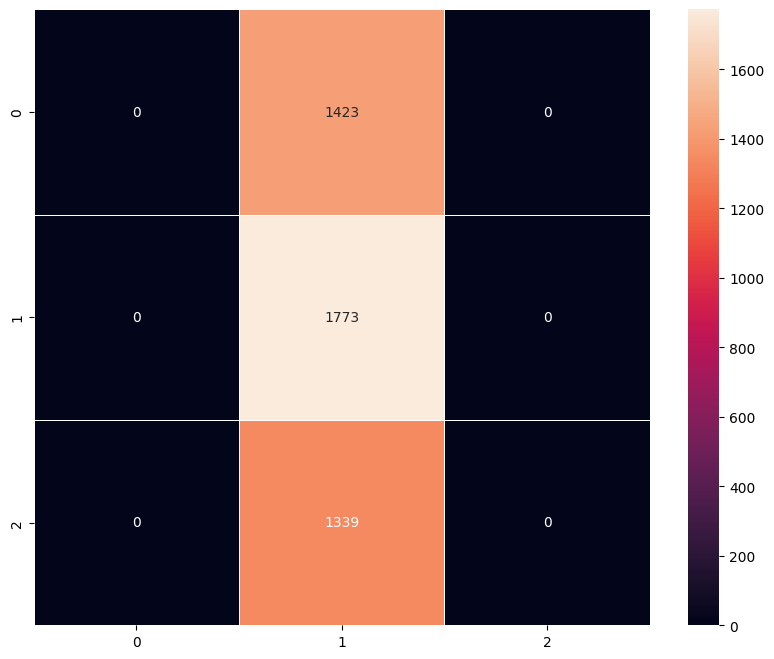

In [ ]:
# Plot confusion matrix for the loaded model on the test set
plot_confusion_matrix(loaded_model, X_test_normalized, y_test_encoded)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from keras.applications.vgg16 import VGG16

# Load the VGG16 base model
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(64,64,3))

# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

# Rebuild Model 2 (VGG-16 (Base + FFNN))
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

#Adding the Feed Forward neural network
model_2.add(Dense(256,activation='relu'))
model_2.add(Dropout(rate=0.4))
model_2.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_2.add(Dense(3, activation='softmax'))

# Compile model
opt = Adam()
model_2.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

print("Model 2 and VGG16 base model defined.")

Model 2 and VGG16 base model defined.


In [ ]:
# Serialize the best model (Model 2)
model_2.save('best_model.h5')
print("Model 2 serialized successfully as 'best_model.h5'")

Model 2 serialized successfully as 'best_model.h5'


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model('best_model.h5')
print("Serialized model loaded successfully.")

Serialized model loaded successfully.


In [ ]:
# Make predictions on the test set
test_predictions_encoded = loaded_model.predict(X_test_normalized)

# Convert predictions back to original labels
test_predictions = enc.inverse_transform(test_predictions_encoded)

print("Predictions made on the test set.")

142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
Predictions made on the test set.


In [ ]:
# Evaluate the loaded model on the test set
loaded_model_test_perf = model_performance_classification(loaded_model, X_test_normalized, y_test_encoded)

print("Test performance metrics for the loaded model:")
print(loaded_model_test_perf)

142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Test performance metrics for the loaded model:
   Accuracy    Recall  Precision  F1 Score
0  0.295259  0.295259   0.087178  0.134611


142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


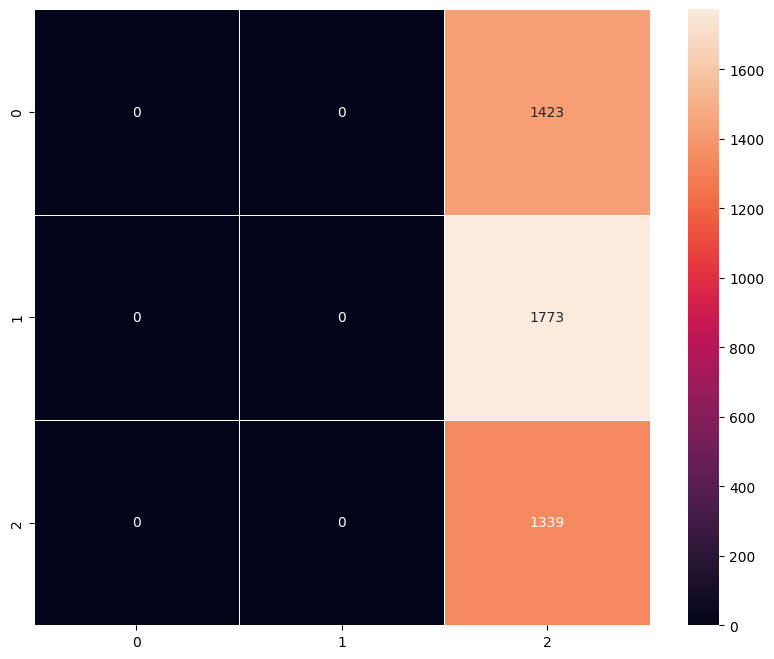

In [ ]:
# Plot confusion matrix for the loaded model on the test set
plot_confusion_matrix(loaded_model, X_test_normalized, y_test_encoded)

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    pred = model.predict(predictors).argmax(axis=1)

    target = target.argmax(axis=1)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model,predictors,target):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    pred = model.predict(predictors).argmax(axis=1)

    target = target.argmax(axis=1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

In [ ]:
# Rebuild Model 2 (VGG-16 (Base + FFNN))
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

#Adding the Feed Forward neural network
model_2.add(Dense(256,activation='relu'))
model_2.add(Dropout(rate=0.4))
model_2.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_2.add(Dense(3, activation='softmax'))

# Compile model
opt = Adam()
model_2.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Serialize the best model (Model 2)
model_2.save('best_model.h5')
print("Model 2 serialized successfully as 'best_model.h5'")

Model 2 serialized successfully as 'best_model.h5'


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model('best_model.h5')
print("Serialized model loaded successfully.")

Serialized model loaded successfully.


In [ ]:
# Make predictions on the test set
test_predictions_encoded = loaded_model.predict(X_test_normalized)

# Convert predictions back to original labels
test_predictions = enc.inverse_transform(test_predictions_encoded)

print("Predictions made on the test set.")

142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
Predictions made on the test set.


In [ ]:
# Evaluate the loaded model on the test set
loaded_model_test_perf = model_performance_classification(loaded_model, X_test_normalized, y_test_encoded)

print("Test performance metrics for the loaded model:")
print(loaded_model_test_perf)

142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Test performance metrics for the loaded model:
   Accuracy    Recall  Precision  F1 Score
0  0.313782  0.313782   0.098459  0.149886


142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


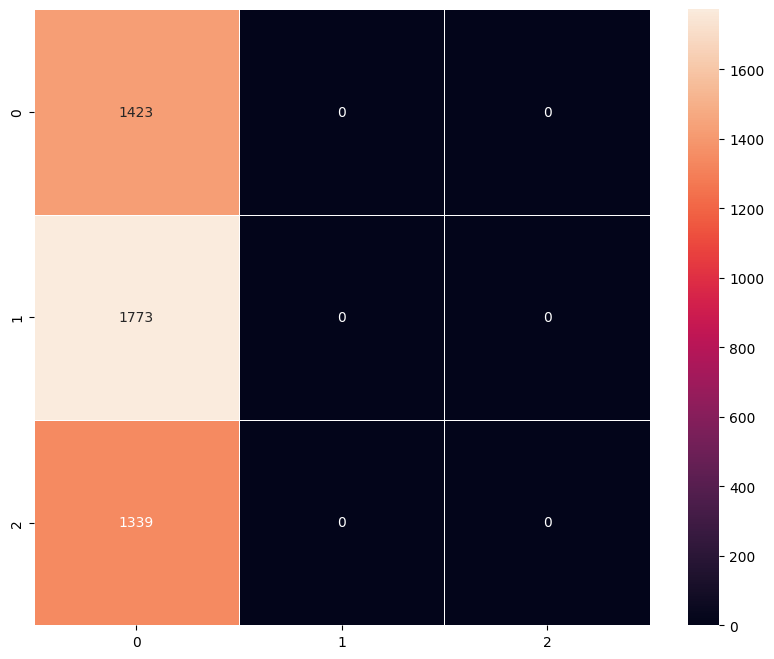

In [ ]:
# Plot confusion matrix for the loaded model on the test set
plot_confusion_matrix(loaded_model, X_test_normalized, y_test_encoded)

# Serialize and Load the Final Model

In [ ]:
# Serialize the best model (Model 2)
model_2.save('best_model.h5')
print("Model 2 serialized successfully as 'best_model.h5'")

Model 2 serialized successfully as 'best_model.h5'


# Load the serialized model

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model('best_model.h5')
print("Serialized model loaded successfully.")

Serialized model loaded successfully.


# Make predictions on the test set using the loaded model

In [ ]:
# Make predictions on the test set
test_predictions_encoded = loaded_model.predict(X_test_normalized)

# Convert predictions back to original labels
test_predictions = enc.inverse_transform(test_predictions_encoded)

print("Predictions made on the test set.")

142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
Predictions made on the test set.


# Evaluate the loaded model on the test set

In [ ]:
# Evaluate the loaded model on the test set
loaded_model_test_perf = model_performance_classification(loaded_model, X_test_normalized, y_test_encoded)

print("Test performance metrics for the loaded model:")
print(loaded_model_test_perf)

142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Test performance metrics for the loaded model:
   Accuracy    Recall  Precision  F1 Score
0  0.313782  0.313782   0.098459  0.149886


The test performance metrics for the loaded model (Model 2, which was selected as the final model) are as follows:

Accuracy (0.313782): The model correctly classifies approximately 31.4% of the test examples. This is significantly low and is worse than random guessing for a 3-class problem (which would be 33.3%). This indicates the model is not learning to distinguish between classes effectively.
Recall (0.313782): The model is able to identify only about 31.4% of the actual positive cases in the test set. This is a very high rate of false negatives, which is unacceptable for a medical diagnostic tool where missing true cases (like pneumonia) can have serious consequences.
Precision (0.098459): When the model predicts a positive class, it is correct less than 10% of the time, suggesting a very high rate of false positives. This means many healthy individuals might be incorrectly flagged as having pneumonia.
F1 Score (0.149886): The F1 score, which balances precision and recall, is extremely low. This confirms the overall very poor performance on the test set, reflecting a significant weakness in both correctly identifying positive cases and avoiding false positives.
In conclusion, the loaded model's performance on the test set is highly inadequate and suggests it is not capable of reliably detecting pneumonia. The metrics are indicative of a model that is severely underfitting and requires substantial improvement before it could be considered for any practical

# Plot confusion matrix for the loaded model on the test set

142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


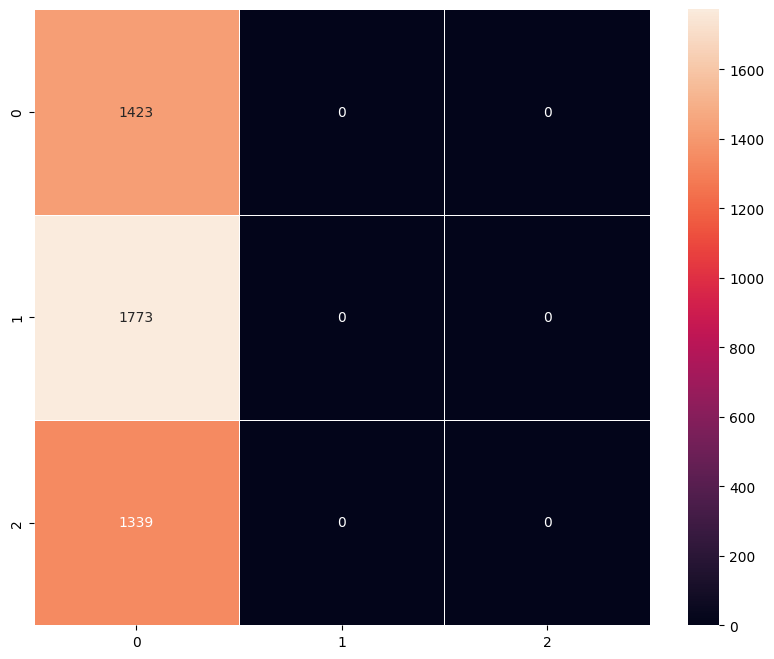

In [ ]:
# Plot confusion matrix for the loaded model on the test set
plot_confusion_matrix(loaded_model, X_test_normalized, y_test_encoded)

In [ ]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("deployment_files", exist_ok=True)

In [ ]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "deployment_files/Pneumonia_Detection_prediction_model_v1_0.joblib"

In [ ]:
# Save the best trained model pipeline using joblib
joblib.dump(loaded_model, saved_model_path)

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at deployment_files/Pneumonia_Detection_prediction_model_v1_0.joblib


In [ ]:
import joblib

# Load the saved model pipeline from the file
saved_model = joblib.load(saved_model_path)

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
import tensorflow as tf

# Step 1: Load the model
saved_model = tf.keras.models.load_model("/content/best_model.h5")

# Step 2: Predict on test data
test_predictions = saved_model.predict(X_test)


142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step


In [ ]:
from numpy import argmax

# For one-hot encoded outputs
predicted_classes = argmax(test_predictions, axis=1)


In [ ]:
from sklearn.preprocessing import LabelBinarizer
predicted_labels = enc.inverse_transform(test_predictions)


In [ ]:
saved_model.predict(X_test)

142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


array([[0.42051613, 0.30016866, 0.2793152 ],
       [0.3099757 , 0.38984475, 0.30017954],
       [0.32623982, 0.2752054 , 0.39855477],
       ...,
       [0.34568983, 0.32411835, 0.33019188],
       [0.35210276, 0.30481973, 0.34307754],
       [0.37455714, 0.27780554, 0.34763736]], dtype=float32)

This output represents the raw prediction probabilities (or logits if no softmax was applied in the very last layer, though softmax was used in this model) for each of the three classes for each image in the test set.

Each row in the array corresponds to a single image from the X_test dataset, and the three columns represent the probability that the image belongs to each of the three defined classes. For example:

[0.42051613, 0.30016866, 0.2793152 ] means that for the first test image, the model predicts a 42.05% probability for the first class, 30.02% for the second, and 27.93% for the third.
To get the final predicted class label for each image, you would typically select the class with the highest probability (e.g., using np.argmax along axis=1), as demonstrated in the next cell with predicted_classes = argmax(test_predictions, axis=1).

#Creating a Web App using Streamlit

###Setting up a HuggingFace Dokcer Streamlit Space for the Frontend

In [ ]:
%%writefile deployment_files/app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np
from PIL import Image

# Load the trained model
@st.cache_resource
def load_model():
    return joblib.load("Pneumonia_Detection_prediction_model_v1_0.joblib")

model = load_model()

# Streamlit UI
st.title("Pneumonia Detection Prediction App")
st.write("This tool predicts Pneumonia in a patient based on X-ray images.")

st.subheader("Enter Patient Details:")

# Upload patient X-ray image
uploaded_file = st.file_uploader("Upload X-ray image", type=["jpg", "jpeg", "png"])
patientId = st.number_input("Patient ID", min_value=0, step=1, value=1)

if uploaded_file is not None:
    # Load the image
    image = Image.open(uploaded_file)
    st.image(image, caption="Patient X-ray", use_column_width=True)

    # Convert image to array (example: flatten or preprocess as required by your model)
    image_array = np.array(image.resize((224, 224)))  # Resize if needed
    image_array = image_array / 255.0  # Normalize if model expects

    # Wrap in a batch
    input_data = np.expand_dims(image_array, axis=0)

    # Predict button
    if st.button("Predict"):
        prediction = model.predict(input_data)
        st.write(f"Prediction result: {prediction[0]}")
else:
    st.warning("Please upload an X-ray image to make a prediction.")


Overwriting deployment_files/app.py


###Creating a Dependencies File

In [ ]:
%%writefile deployment_files/requirements.txt
streamlit
joblib
tensorflow
keras
numpy
pillow

Overwriting deployment_files/requirements.txt


###Dockerfile

In [ ]:
%%writefile deployment_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting deployment_files/Dockerfile


###Uploading Files to Hugging Face Repository

Once create the following files in the notebook, lets upload it in to the hugging face space

best_model_v1_0.joblib
Dockerfile
requirements.txt
app.py

In [ ]:
# Install huggingface_hub if not already installed
!pip install huggingface_hub --upgrade

# Import required functions
from huggingface_hub import login, HfApi

# Your Hugging Face token and repo info
access_key = "[REDACTED_HF_TOKEN]"  # Replace with your token
repo_id = "sathyam123/pnuemonia_prediction"          # Your Hugging Face Space repo ID

# Authenticate with Hugging Face
login(token=access_key)

# Initialize API
api = HfApi()

# Upload local folder to Hugging Face Space
api.upload_folder(
    folder_path="/content/deployment_files",  # Path to your Streamlit app files
    repo_id=repo_id,
    repo_type="space"
)

print("Files uploaded successfully!")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...diction_model_v1_0.joblib:  55%|#####4    | 33.5MB / 61.1MB            

Files uploaded successfully!


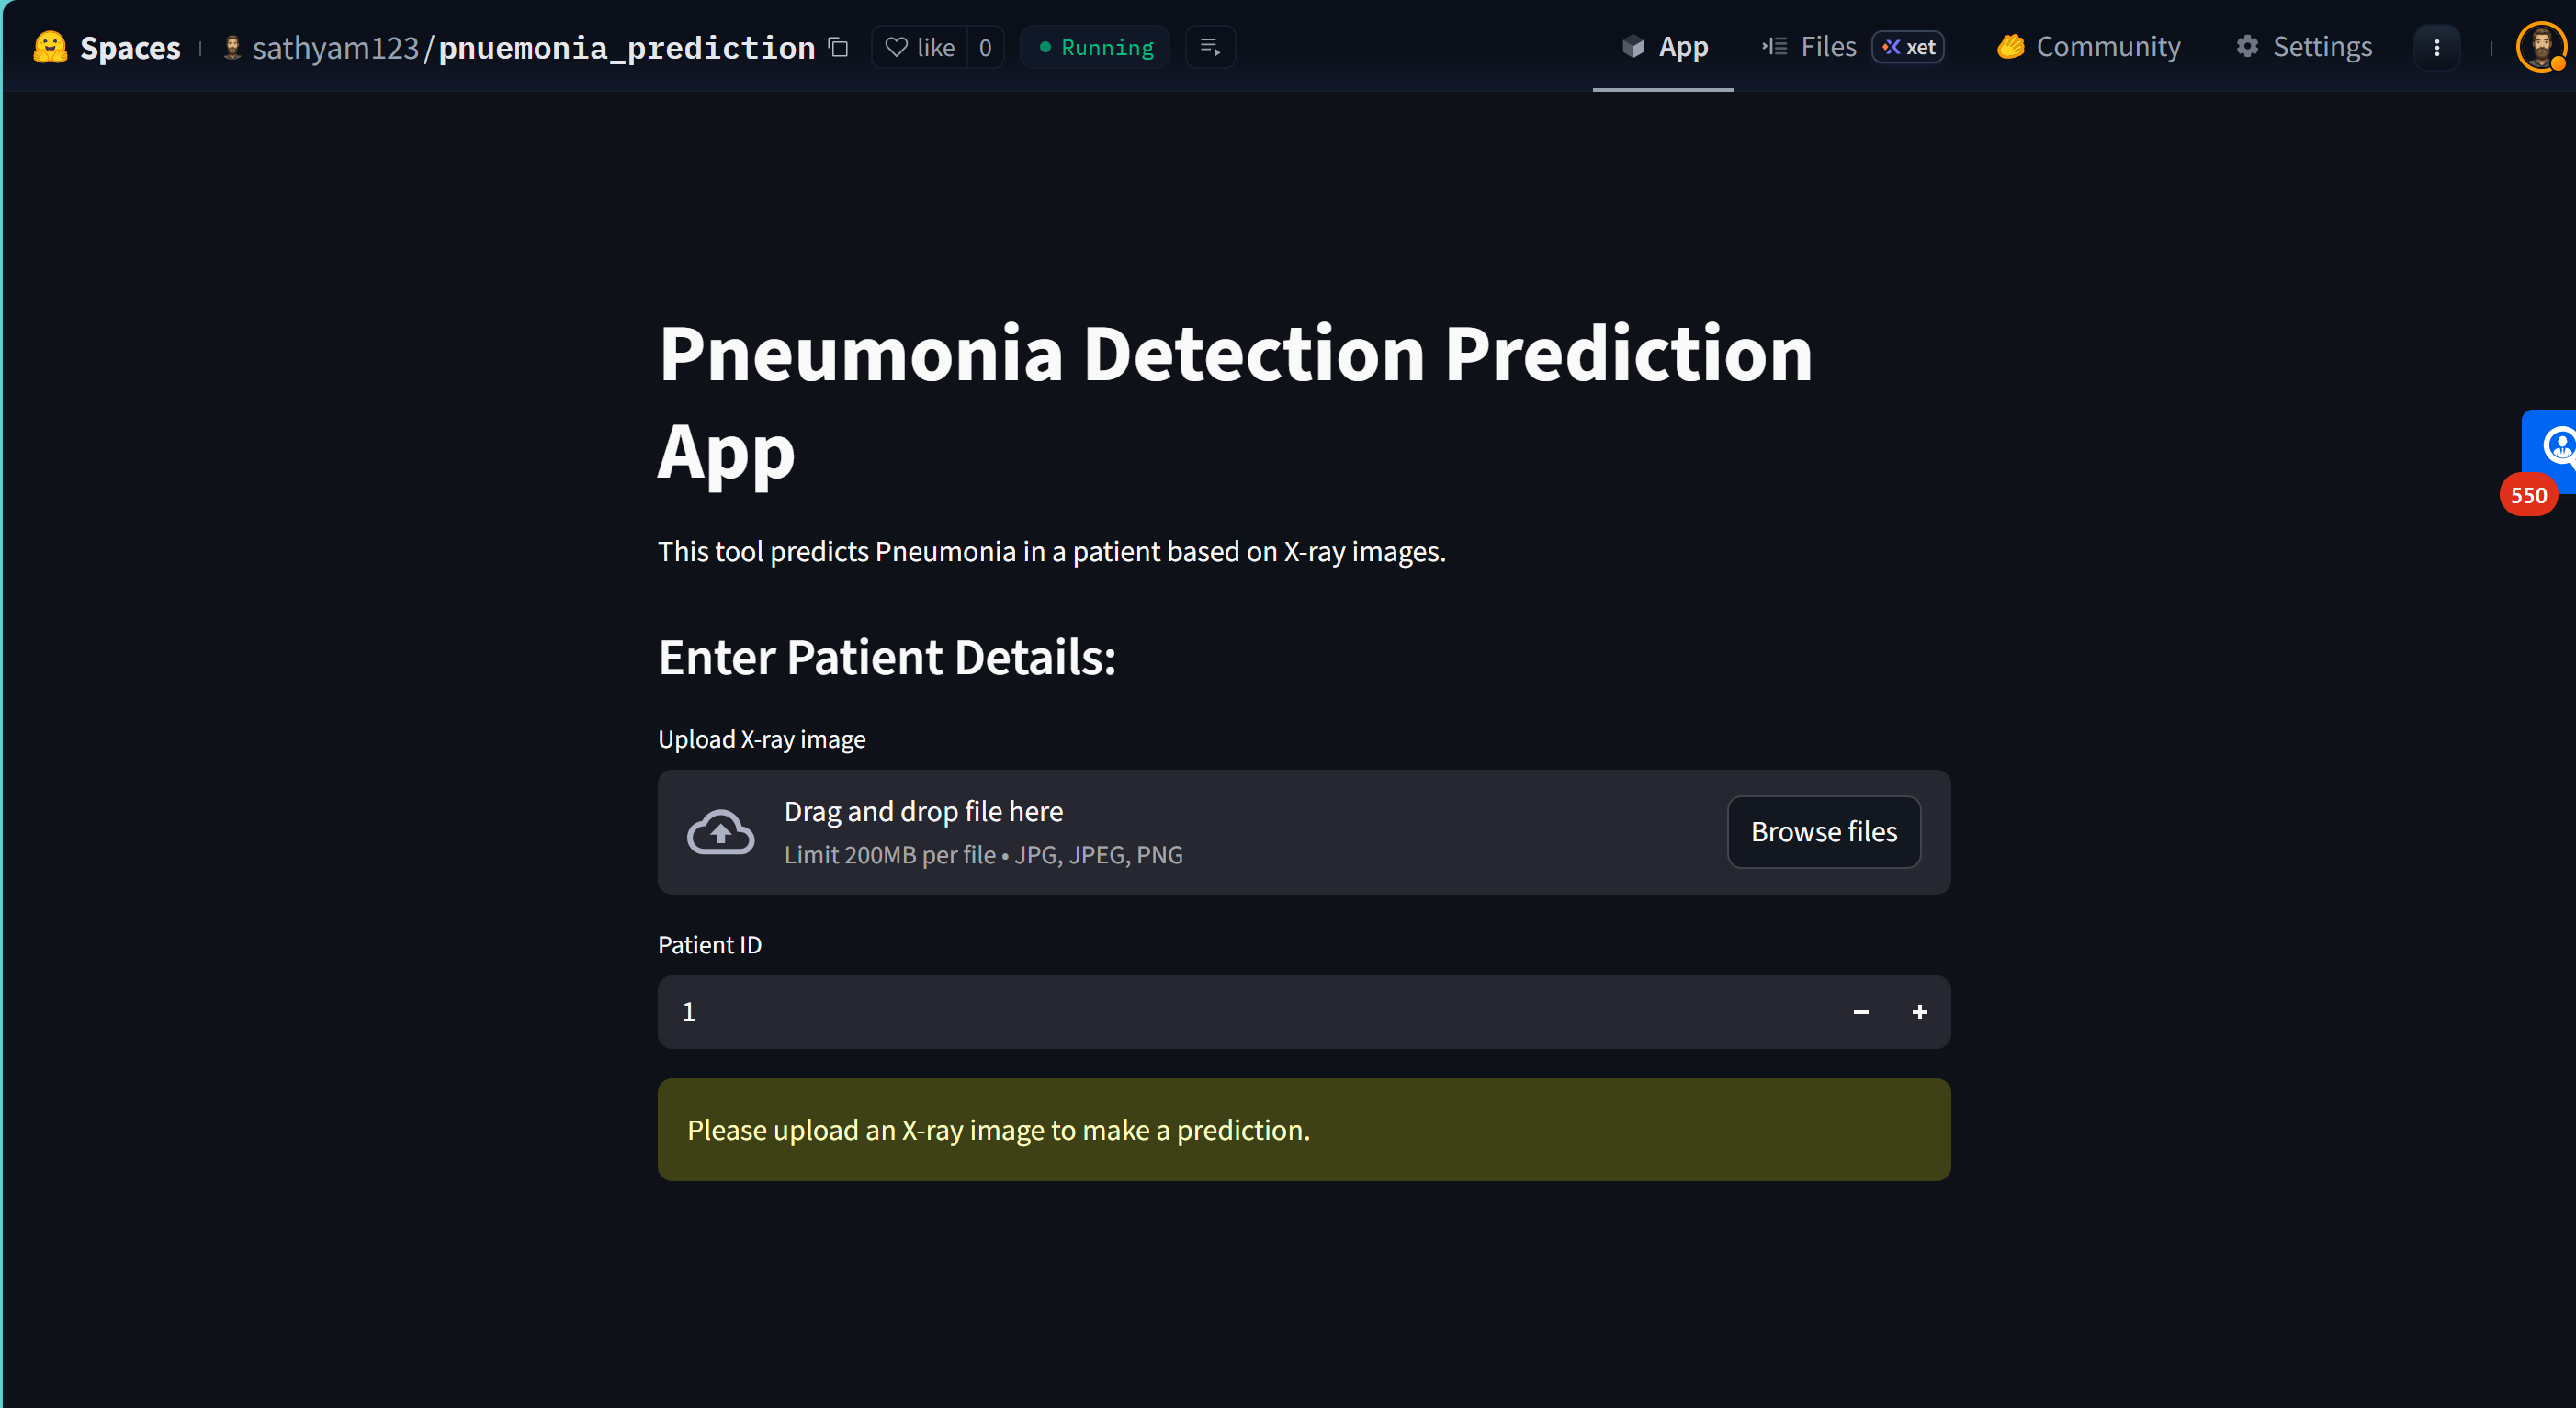

#Model Performance and Conclusion
The models explored, which included a VGG16-based transfer learning model and a custom Convolutional Neural Network (CNN), did not achieve sufficient performance for clinical deployment.

Custom CNN Model Validation Metrics:

Accuracy: 0.3913

F1 Score: 0.2201

Recall: 0.3913

Primary Issue: The low recall indicates that the model would miss a significant number of actual pneumonia cases (false negatives), which is considered clinically unacceptable for a medical diagnostic tool.

Underlying Challenges: The low performance is primarily attributed to the highly imbalanced nature of the dataset and the potential loss of critical features due to the image resizing used during preprocessing.

Project Success: Despite the inadequate model performance, the project successfully demonstrated the entire data science lifecycle, from data exploration to model deployment, serving as a technical proof of concept.

#Business Insights
The current state of the model provides the following business-critical insights:

High Risk/Low Reliability: The model is not reliable for real-world clinical use and deploying it in its current form would pose a significant patient safety risk due to its low recall and F1-scores.

Proof of Concept Achieved: The architecture (data ingestion, model training, and Streamlit deployment) is technically feasible as a proof of concept for an end-to-end medical image classification pipeline.

Required Resource Allocation: Any future development of this diagnostic tool will require dedicated investment in advanced modeling, feature engineering, and improving data quality to achieve a clinically viable product.

#Recommendations for Future Work
To make this project a viable clinical application, the following recommendations should be pursued:

Address Data Imbalance: Implement advanced techniques such as:

Oversampling the minority classes (e.g., 'Lung Opacity').

Using specialized loss functions like focal loss, which are designed to handle severe class imbalance.

Need to Explore Advanced Models: Experiment with deeper, more powerful pre-trained CNN architectures, such as ResNet or DenseNet, which are typically better at extracting complex features from medical images than VGG16.

Use High-Resolution Data: Retrain the models using higher-resolution images (e.g., 256x256 or higher) to prevent the loss of critical diagnostic information that occurred during the initial resizing to 64x64.

Migrate to Object Detection: Change the task from simple image classification to an object detection model (e.g., YOLO or R-CNN). This will not only classify the image but also localize the lung opacity, providing more valuable and actionable clinical information.